In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 50)


# Corporate Announcement Event Study

## 1. Project Overview

This project analyzes how stock prices and trading volume react to corporate announcements over short intraday horizons.

The analysis examines:
- 5-minute
- 30-minute
- 60-minute

post-announcement windows across different corporate announcement categories.

The objective is to identify whether different types of announcements are associated with statistically significant changes in stock returns and trading activity.

## 2. Business Questions

1. Do corporate announcements generate abnormal short-term stock returns?
2. Does the market reaction differ by announcement type?
3. How does trading volume change following announcements?
4. Are the observed effects statistically significant after correcting for multiple comparisons?
5. Are the findings robust to extreme observations?

## 3. Data Loading

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

print("Project folder:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())


Project folder: C:\IndoThai_Quant_Assessment
Data folder: C:\IndoThai_Quant_Assessment\data
Data folder exists: True


In [3]:
files = list(DATA_DIR.iterdir())

for file in files:
    print(file.name)

.ipynb_checkpoints
corporate_announcements.csv
corporate_announcements.jsonl
HAL.csv
HDFCBANK.csv
metadata.json
NYKAA.csv
RELIANCE.csv
RVNL.csv


In [4]:
announcements = pd.read_csv(
    DATA_DIR / "corporate_announcements.csv"
)

print("Rows:", len(announcements))
print("Columns:", len(announcements.columns))

Rows: 2530
Columns: 28


In [5]:
stock_files = {
    "RELIANCE": "RELIANCE.csv",
    "HDFCBANK": "HDFCBANK.csv",
    "NYKAA": "NYKAA.csv",
    "RVNL": "RVNL.csv",
    "HAL": "HAL.csv"
}

stocks = {}

for ticker, filename in stock_files.items():
    df = pd.read_csv(DATA_DIR / filename)

    df["date"] = pd.to_datetime(
        df["date"],
        format="ISO8601",
        errors="coerce"
    )

    stocks[ticker] = df

    print(
        ticker,
        "| Rows:", len(df),
        "| Invalid dates:", df["date"].isna().sum(),
        "| Duplicate timestamps:", df["date"].duplicated().sum(),
        "| Missing values:", df.isna().sum().sum()
    )

RELIANCE | Rows: 277510 | Invalid dates: 0 | Duplicate timestamps: 0 | Missing values: 0
HDFCBANK | Rows: 277510 | Invalid dates: 0 | Duplicate timestamps: 0 | Missing values: 0
NYKAA | Rows: 277508 | Invalid dates: 0 | Duplicate timestamps: 0 | Missing values: 0
RVNL | Rows: 277509 | Invalid dates: 0 | Duplicate timestamps: 0 | Missing values: 0
HAL | Rows: 277510 | Invalid dates: 0 | Duplicate timestamps: 0 | Missing values: 0


## 4. Data Cleaning and Validation

In [6]:
display(announcements.head())
announcements.info()

missing = announcements.isna().sum()
print("\nMissing values (columns with at least one missing value):")
print(missing[missing > 0].sort_values(ascending=False))

print("\nColumns:", announcements.columns.tolist())


,NEWSID,SCRIP_CD,XML_NAME,NEWSSUB,DT_TM,NEWS_DT,CRITICALNEWS,ANNOUNCEMENT_TYPE,QUARTER_ID,FILESTATUS,ATTACHMENTNAME,MORE,HEADLINE,CATEGORYNAME,OLD,RN,PDFFLAG,NSURL,SLONGNAME,AGENDA_ID,News_submission_dt,DissemDT,TimeDiff,Fld_Attachsize,SUBCATNAME,BSENewsid,Investor_Presentation,AUDIO_VIDEO_FILE
0,d4395f8a-6089-4a17-8dec-385a6acb2b67,500180,ANN_500180_D4395F8A-6089-4A17-8DEC-385A6ACB2B67,Announcement under Regulation 30 (LODR)-Credit...,2026-08-19T23:19:39.42,2026-08-19T23:19:39.42,1,A,NaN,N,b0669fd5-958c-4571-8069-e0b011152213.pdf,NaN,Intimation of Credit Rating pursuant to Regula...,Company Update,1,1,0,https://www.bseindia.com/stock-share-price/hdf...,HDFC Bank Ltd,46,2026-08-19T23:19:39,2026-08-19T23:19:39.42,00:00:00,967155.0,Credit Rating,NaN,NaN,NaN
1,391541fa-8d4b-41b6-9304-1e15bed1d5d8,500180,ANN_500180_391541FA-8D4B-41B6-9304-1E15BED1D5D8,Intimation Under Securities And Exchange Board...,2026-08-19T22:52:54.67,2026-08-19T22:52:54.67,0,A,NaN,N,35365c1b-d016-4b65-8fee-a9c6e6818e55.pdf,NaN,Intimation under Securities and Exchange Board...,Company Update,1,1,0,https://www.bseindia.com/stock-share-price/hdf...,HDFC Bank Ltd,1,2026-08-19T22:52:54,2026-08-19T22:52:54.67,00:00:00,618910.0,General,NaN,NaN,NaN
2,989d8d2f-2b08-4a1c-8d43-f55bae61c178,500325,ANN_500325_989D8D2F-2B08-4A1C-8D43-F55BAE61C178,Update On Institutional Investors'' Meeting - ...,2026-08-18T20:06:38.747,2026-08-18T20:06:38.747,0,A,NaN,N,27647703-eded-4e63-a04e-5778b54afcb8.pdf,This is further to the disclosure dated August...,This is further to the disclosure dated August...,Company Update,1,1,0,https://www.bseindia.com/stock-share-price/rel...,Reliance Industries Ltd,1,2026-08-18T20:06:38,2026-08-18T20:06:38.747,00:00:00,238773.0,General,NaN,NaN,NaN
3,b0bc3391-c0aa-44d6-be8d-a10b20b10247,500325,ANN_500325_B0BC3391-C0AA-44D6-BE8D-A10B20B10247,"News Clarification - ""SC Slaps Rs 10 Lakh Fine...",2026-08-18T17:44:19.31,2026-08-18T17:44:19.31,0,A,NaN,N,316b5fc6-c19f-4ec6-ab07-43cef96d8be3.pdf,NaN,"Please refer our letter dated August 18, 2026 ...",Company Update,1,1,0,https://www.bseindia.com/stock-share-price/rel...,Reliance Industries Ltd,1,2026-08-18T17:44:19,2026-08-18T17:44:19.31,00:00:00,275828.0,General,NaN,NaN,NaN
4,32de7735-b8e6-4653-b377-0c5762be73af,542649,ANN_542649_32DE7735-B8E6-4653-B377-0C5762BE73AF,Announcement under Regulation 30 (LODR)-Earnin...,2026-08-18T14:24:13.29,2026-08-18T14:24:13.29,0,A,NaN,N,8290c987-c721-40b3-b8ed-92b08c369c84.pdf,NaN,Transcript of Conference Call with Investors,Company Update,1,1,0,https://www.bseindia.com/stock-share-price/rai...,Rail Vikas Nigam Ltd,157,2026-08-18T14:24:13,2026-08-18T14:24:13.29,00:00:00,602505.0,Earnings Call Transcript,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NEWSID                 2530 non-null   str    
 1   SCRIP_CD               2530 non-null   int64  
 2   XML_NAME               2530 non-null   str    
 3   NEWSSUB                2530 non-null   str    
 4   DT_TM                  2530 non-null   str    
 5   NEWS_DT                2530 non-null   str    
 6   CRITICALNEWS           2530 non-null   int64  
 7   ANNOUNCEMENT_TYPE      2530 non-null   str    
 8   QUARTER_ID             0 non-null      float64
 9   FILESTATUS             2530 non-null   str    
 10  ATTACHMENTNAME         2510 non-null   str    
 11  MORE                   383 non-null    str    
 12  HEADLINE               2530 non-null   str    
 13  CATEGORYNAME           2530 non-null   str    
 14  OLD                    2530 non-null   int64  
 15  RN             

In [7]:
print("Duplicate NEWSID:", announcements["NEWSID"].duplicated().sum())

print(
    "Duplicate complete rows:",
    announcements.duplicated().sum()
)

Duplicate NEWSID: 0
Duplicate complete rows: 0


In [8]:
duplicate_ids = announcements[
    announcements["NEWSID"].duplicated(keep=False)
].sort_values("NEWSID")

duplicate_ids[["NEWSID", "SCRIP_CD", "DT_TM", "DissemDT", "HEADLINE"]]

,NEWSID,SCRIP_CD,DT_TM,DissemDT,HEADLINE


In [9]:
announcements["SCRIP_CD"].value_counts()

SCRIP_CD
500325    844
500180    607
542649    464
543384    339
541154    276
Name: count, dtype: int64

In [10]:
print(announcements[["DT_TM", "DissemDT"]].head(10).to_string())
print("\nDT_TM missing:", announcements["DT_TM"].isna().sum())
print("DissemDT missing:", announcements["DissemDT"].isna().sum())


                     DT_TM                 DissemDT
0   2026-08-19T23:19:39.42   2026-08-19T23:19:39.42
1   2026-08-19T22:52:54.67   2026-08-19T22:52:54.67
2  2026-08-18T20:06:38.747  2026-08-18T20:06:38.747
3   2026-08-18T17:44:19.31   2026-08-18T17:44:19.31
4   2026-08-18T14:24:13.29   2026-08-18T14:24:13.29
5  2026-08-17T17:18:06.063  2026-08-17T17:18:06.063
6  2026-08-16T19:43:27.497  2026-08-16T19:43:27.497
7   2026-08-14T18:22:56.08   2026-08-14T18:22:56.08
8  2026-08-14T17:45:54.693  2026-08-14T17:45:54.693
9  2026-08-14T14:10:20.837  2026-08-14T14:10:20.837

DT_TM missing: 0
DissemDT missing: 0


In [11]:
raw_announcements = pd.read_csv(
    DATA_DIR / "corporate_announcements.csv"
)

print(raw_announcements.shape)

(2530, 28)


In [12]:
raw_announcements["DT_TM"] = pd.to_datetime(
    raw_announcements["DT_TM"],
    format="ISO8601",
    errors="coerce"
)

raw_announcements["DissemDT"] = pd.to_datetime(
    raw_announcements["DissemDT"],
    format="ISO8601",
    errors="coerce"
)

In [13]:
print("Invalid DT_TM:", raw_announcements["DT_TM"].isna().sum())
print("Invalid DissemDT:", raw_announcements["DissemDT"].isna().sum())

Invalid DT_TM: 0
Invalid DissemDT: 0


In [14]:
announcements = raw_announcements.copy()

print("Rows:", len(announcements))
print("Columns:", len(announcements.columns))

Rows: 2530
Columns: 28


In [15]:
print("Earliest announcement:")
print(announcements["DissemDT"].min())

print("\nLatest announcement:")
print(announcements["DissemDT"].max())

Earliest announcement:
2023-08-21 18:16:15.450000

Latest announcement:
2026-08-19 23:19:39.420000


In [16]:
time_difference = (
    announcements["DissemDT"] -
    announcements["DT_TM"]
)

print(time_difference.describe())

count                      2530
mean     0 days 00:00:00.000150
std      0 days 00:00:00.006110
min             0 days 00:00:00
25%             0 days 00:00:00
50%             0 days 00:00:00
75%             0 days 00:00:00
max      0 days 00:00:00.307000
dtype: object


In [17]:
different_timestamps = (
    announcements["DT_TM"] != announcements["DissemDT"]
).sum()

print(
    "Announcements where DT_TM and DissemDT differ:",
    different_timestamps
)

Announcements where DT_TM and DissemDT differ: 24


In [18]:
different = announcements[
    announcements["DT_TM"] != announcements["DissemDT"]
]

print(
    different[
        [
            "SCRIP_CD",
            "DT_TM",
            "DissemDT",
            "TimeDiff",
            "HEADLINE"
        ]
    ].to_string(index=False)
)

 SCRIP_CD                   DT_TM                DissemDT TimeDiff                                                                                                                                                                                            HEADLINE
   541154 2026-08-04 10:49:02.237 2026-08-04 10:49:02.240 00:00:00                                                                                                                                                                               Announcement attached
   500180 2026-03-16 17:28:11.197 2026-03-16 17:28:11.200 00:00:00                                                                                                                                                   Allotment of 1630554 equity shares under ESOP/RSU
   500325 2026-02-11 19:28:12.147 2026-02-11 19:28:12.150 00:00:00   This is further to the disclosure dated February 6, 2026 made by the Company. We wish to inform you that the Company executives participated i

In [19]:
hour_counts = (
    announcements["DissemDT"]
    .dt.hour
    .value_counts()
    .sort_index()
)

print(hour_counts.to_string())

DissemDT
0       9
1       1
2       2
6       2
7       6
8      24
9      50
10     56
11     70
12    107
13     98
14    149
15    201
16    330
17    339
18    403
19    307
20    144
21    104
22     84
23     44


In [20]:
for ticker, df in stocks.items():

    invalid_ohlc = (
        (df["high"] < df["open"]) |
        (df["high"] < df["close"]) |
        (df["low"] > df["open"]) |
        (df["low"] > df["close"]) |
        (df["high"] < df["low"])
    )

    print(
        ticker,
        "| Invalid OHLC:", invalid_ohlc.sum(),
        "| Zero volume:", (df["volume"] == 0).sum(),
        "| Negative volume:", (df["volume"] < 0).sum()
    )

RELIANCE | Invalid OHLC: 0 | Zero volume: 190 | Negative volume: 0
HDFCBANK | Invalid OHLC: 1 | Zero volume: 187 | Negative volume: 0
NYKAA | Invalid OHLC: 0 | Zero volume: 191 | Negative volume: 0
RVNL | Invalid OHLC: 0 | Zero volume: 191 | Negative volume: 0
HAL | Invalid OHLC: 1 | Zero volume: 187 | Negative volume: 0


In [21]:
for ticker, df in stocks.items():

    df = df.sort_values("date").copy()

    df["trading_date"] = df["date"].dt.date

    gaps = (
        df.groupby("trading_date")["date"]
        .apply(lambda x: x.sort_values().diff().dropna().dt.total_seconds().gt(60).sum())
        .sum()
    )

    print(ticker, "| Gaps > 1 minute:", int(gaps))

RELIANCE | Gaps > 1 minute: 4
HDFCBANK | Gaps > 1 minute: 4
NYKAA | Gaps > 1 minute: 4
RVNL | Gaps > 1 minute: 3
HAL | Gaps > 1 minute: 4


In [22]:
for ticker, df in stocks.items():

    invalid_ohlc = (
        (df["high"] < df["open"]) |
        (df["high"] < df["close"]) |
        (df["low"] > df["open"]) |
        (df["low"] > df["close"]) |
        (df["high"] < df["low"])
    )

    if invalid_ohlc.any():
        print("\n", ticker)
        print(
            df.loc[
                invalid_ohlc,
                ["date", "open", "high", "low", "close", "volume", "oi"]
            ].to_string(index=False)
        )


 HDFCBANK
               date  open  high   low  close   volume  oi
2024-06-25 09:15:00 835.6 839.8 837.4  839.6 370096.0   0

 HAL
               date   open   high    low  close  volume  oi
2024-06-25 09:15:00 5375.0 5368.0 5347.6 5368.0 72552.0   0


In [23]:
for ticker, df in stocks.items():

    zero_volume = df[df["volume"] == 0]

    print(
        "\n", ticker,
        "| Zero-volume rows:", len(zero_volume)
    )

    print(
        zero_volume[
            ["date", "open", "high", "low", "close", "volume"]
        ].head(5).to_string(index=False)
    )


 RELIANCE | Zero-volume rows: 190
               date    open    high     low   close  volume
2024-04-23 10:54:00 1473.60 1473.60 1473.60 1473.60     0.0
2024-09-30 15:27:00 1476.00 1476.00 1476.00 1476.00     0.0
2024-10-01 13:29:00 1465.70 1465.70 1465.70 1465.70     0.0
2024-12-17 10:07:00 1252.80 1252.80 1252.80 1252.80     0.0
2024-12-23 13:28:00 1215.35 1215.35 1215.35 1215.35     0.0

 HDFCBANK | Zero-volume rows: 187
               date  open  high   low  close  volume
2024-04-23 10:54:00 755.7 755.7 755.7  755.7     0.0
2024-04-25 09:34:00 756.8 756.8 756.6  756.8     0.0
2024-09-30 15:06:00 865.6 865.6 865.6  865.6     0.0
2025-03-11 10:42:00 845.2 845.2 845.2  845.2     0.0
2025-03-11 11:24:00 844.0 844.0 844.0  844.0     0.0

 NYKAA | Zero-volume rows: 191
               date   open   high    low  close  volume
2023-11-01 11:05:00 140.35 140.35 140.35 140.35     0.0
2023-11-01 12:51:00 139.35 139.35 139.35 139.35     0.0
2024-04-23 10:50:00 169.95 170.00 169.95 169.95     

In [24]:
for ticker, df in stocks.items():

    df = df.sort_values("date").copy()
    diff = df["date"].diff()

    gaps = df.loc[
        diff > pd.Timedelta(minutes=1),
        ["date"]
    ].copy()

    gaps["previous_bar"] = df["date"].shift(1).loc[gaps.index]

    gaps["gap_minutes"] = (
        gaps["date"] - gaps["previous_bar"]
    ).dt.total_seconds() / 60

    print("\n================", ticker, "================")
    
    if len(gaps) == 0:
        print("No gaps")
    else:
        print(
            gaps[
                ["previous_bar", "date", "gap_minutes"]
            ].to_string(index=False)
        )


================ RELIANCE ================
       previous_bar                date  gap_minutes
2023-08-21 15:29:00 2023-08-22 09:15:00       1066.0
2023-08-22 15:29:00 2023-08-23 09:15:00       1066.0
2023-08-23 15:29:00 2023-08-24 09:15:00       1066.0
2023-08-24 15:29:00 2023-08-25 09:15:00       1066.0
2023-08-25 15:29:00 2023-08-28 09:15:00       3946.0
2023-08-28 15:29:00 2023-08-29 09:15:00       1066.0
2023-08-29 15:29:00 2023-08-30 09:15:00       1066.0
2023-08-30 15:29:00 2023-08-31 09:15:00       1066.0
2023-08-31 15:29:00 2023-09-01 09:15:00       1066.0
2023-09-01 15:29:00 2023-09-04 09:15:00       3946.0
2023-09-04 15:29:00 2023-09-05 09:15:00       1066.0
2023-09-05 15:29:00 2023-09-06 09:15:00       1066.0
2023-09-06 15:29:00 2023-09-07 09:15:00       1066.0
2023-09-07 15:29:00 2023-09-08 09:15:00       1066.0
2023-09-08 15:29:00 2023-09-11 09:15:00       3946.0
2023-09-11 15:29:00 2023-09-12 09:15:00       1066.0
2023-09-12 15:29:00 2023-09-13 09:15:00       1066.0
20

In [25]:
# Remove invalid OHLC bars directly from the working `stocks` dict so every
# downstream step (event alignment, returns, volume) uses cleaned data.
for ticker, df in stocks.items():
    df = df.sort_values("date").reset_index(drop=True)

    invalid_ohlc = (
        (df["high"] < df["open"]) |
        (df["high"] < df["close"]) |
        (df["low"] > df["open"]) |
        (df["low"] > df["close"]) |
        (df["high"] < df["low"])
    )

    n_removed = invalid_ohlc.sum()
    stocks[ticker] = df.loc[~invalid_ohlc].reset_index(drop=True)

    print(
        ticker,
        "| Removed invalid OHLC bars:", n_removed,
        "| Remaining:", len(stocks[ticker])
    )


RELIANCE | Removed invalid OHLC bars: 0 | Remaining: 277510
HDFCBANK | Removed invalid OHLC bars: 1 | Remaining: 277509
NYKAA | Removed invalid OHLC bars: 0 | Remaining: 277508
RVNL | Removed invalid OHLC bars: 0 | Remaining: 277509
HAL | Removed invalid OHLC bars: 1 | Remaining: 277509


## 5. Event Identification and Alignment

In [26]:
stock_map = {
    500325: "RELIANCE",
    500180: "HDFCBANK",
    543384: "NYKAA",
    541154: "HAL",
    542649: "RVNL"
}

announcements["ticker"] = announcements["SCRIP_CD"].map(stock_map)

print(
    announcements[
        ["SCRIP_CD", "ticker"]
    ].drop_duplicates()
    .sort_values("SCRIP_CD")
    .to_string(index=False)
)

print("\nUnmapped announcements:", announcements["ticker"].isna().sum())

 SCRIP_CD   ticker
   500180 HDFCBANK
   500325 RELIANCE
   541154      HAL
   542649     RVNL
   543384    NYKAA

Unmapped announcements: 0


In [27]:
ann = announcements.copy()
ann["DissemDT"] = pd.to_datetime(ann["DissemDT"])

# Classify announcement timing
def classify_timing(t):
    t = t.time()

    if t < pd.Timestamp("09:15").time():
        return "Pre-market"
    elif t <= pd.Timestamp("15:30").time():
        return "During-market"
    else:
        return "After-market"

ann["market_timing"] = ann["DissemDT"].apply(classify_timing)

# Find the first trading bar at or after announcement time
def find_event_bar(row):
    ticker = row["ticker"]
    announcement_time = row["DissemDT"]

    prices = stocks[ticker]
    candidates = prices[prices["date"] >= announcement_time]

    if candidates.empty:
        return pd.NaT

    return candidates.iloc[0]["date"]

ann["event_time_correct"] = ann.apply(find_event_bar, axis=1)

print("Total announcements:", len(ann))
print("Successfully aligned:", ann["event_time_correct"].notna().sum())
print("Unaligned:", ann["event_time_correct"].isna().sum())

print("\nTiming alignment:")
print(
    ann[
        ["ticker", "DissemDT", "market_timing", "event_time_correct"]
    ].head(15).to_string(index=False)
)

Total announcements: 2530
Successfully aligned: 2528
Unaligned: 2

Timing alignment:
  ticker                DissemDT market_timing  event_time_correct
HDFCBANK 2026-08-19 23:19:39.420  After-market                 NaT
HDFCBANK 2026-08-19 22:52:54.670  After-market                 NaT
RELIANCE 2026-08-18 20:06:38.747  After-market 2026-08-19 09:15:00
RELIANCE 2026-08-18 17:44:19.310  After-market 2026-08-19 09:15:00
    RVNL 2026-08-18 14:24:13.290 During-market 2026-08-18 14:25:00
RELIANCE 2026-08-17 17:18:06.063  After-market 2026-08-18 09:15:00
HDFCBANK 2026-08-16 19:43:27.497  After-market 2026-08-17 09:15:00
    RVNL 2026-08-14 18:22:56.080  After-market 2026-08-17 09:15:00
RELIANCE 2026-08-14 17:45:54.693  After-market 2026-08-17 09:15:00
HDFCBANK 2026-08-14 14:10:20.837 During-market 2026-08-14 14:11:00
RELIANCE 2026-08-13 19:40:26.910  After-market 2026-08-14 09:15:00
    RVNL 2026-08-13 18:10:55.750  After-market 2026-08-14 09:15:00
HDFCBANK 2026-08-13 16:21:49.777  After-mark

In [28]:
print(
    ann[ann["event_time_correct"].isna()][
        ["ticker", "DissemDT", "HEADLINE"]
    ].to_string(index=False)
)

  ticker                DissemDT                                                                                                                                                       HEADLINE
HDFCBANK 2026-08-19 23:19:39.420 Intimation of Credit Rating pursuant to Regulation 30 of SEBI (Listing Obligations and Disclosure Requirements) Regulations, 2015 ("SEBI Listing Regulations")
HDFCBANK 2026-08-19 22:52:54.670       Intimation under Securities and Exchange Board of India (Listing Obligations and Disclosure Requirements) Regulations, 2015 ("SEBI Listing Regulations")


In [29]:
# Create final event dataset using successfully aligned announcements

events = ann[ann["event_time_correct"].notna()].copy()

print("Final aligned announcements:", len(events))
print("Excluded announcements:", ann["event_time_correct"].isna().sum())

print("\nEvent timing:")
print(
    events["market_timing"].value_counts()
)

print("\nEvents by ticker:")
print(
    events["ticker"].value_counts()
)

Final aligned announcements: 2528
Excluded announcements: 2

Event timing:
market_timing
After-market     1874
During-market     594
Pre-market         60
Name: count, dtype: int64

Events by ticker:
ticker
RELIANCE    844
HDFCBANK    605
RVNL        464
NYKAA       339
HAL         276
Name: count, dtype: int64


In [30]:
print(
    events[
        [
            "ticker",
            "DissemDT",
            "market_timing",
            "event_time_correct",
            "HEADLINE"
        ]
    ].head(10).to_string(index=False)
)

  ticker                DissemDT market_timing  event_time_correct                                                                                                                                                                                                                                                                                                                                                            HEADLINE
RELIANCE 2026-08-18 20:06:38.747  After-market 2026-08-19 09:15:00                                                                                                                                                                 This is further to the disclosure dated August 13, 2026 made by the Company. We wish to inform you that the Company executives participated in the Institutional Investors'' Meeting - Motilal ....
RELIANCE 2026-08-18 17:44:19.310  After-market 2026-08-19 09:15:00                                                                                        

In [31]:
# Count announcements by ticker and trading session
daily_counts = (
    events
    .assign(trading_date=events["event_time_correct"].dt.date)
    .groupby(["ticker", "trading_date"])
    .size()
    .reset_index(name="announcement_count")
)

print("daily_counts created:", daily_counts.shape)


daily_counts created: (1515, 3)


In [32]:
df = daily_counts

print("Total announcement-event rows:", len(df))

print(
    "Maximum announcements on one trading session:",
    df["announcement_count"].max()
)

print("\nTop 10 busiest announcement sessions:")
print(
    df.sort_values("announcement_count", ascending=False)
      .head(10)
      .to_string(index=False)
)

print("\nAnnouncement counts by ticker:")
print(
    df.groupby("ticker")["announcement_count"]
      .agg(
          trading_sessions="count",
          total_announcements="sum",
          max_announcements="max"
    )
)

Total announcement-event rows: 1515
Maximum announcements on one trading session: 9

Top 10 busiest announcement sessions:
  ticker trading_date  announcement_count
HDFCBANK   2024-07-22                   9
HDFCBANK   2025-04-21                   9
HDFCBANK   2024-04-22                   9
   NYKAA   2025-06-02                   8
   NYKAA   2024-08-14                   8
RELIANCE   2024-01-20                   8
RELIANCE   2025-04-28                   8
   NYKAA   2025-08-13                   8
   NYKAA   2025-11-10                   8
RELIANCE   2025-01-17                   8

Announcement counts by ticker:
          trading_sessions  total_announcements  max_announcements
ticker                                                            
HAL                    189                  276                  5
HDFCBANK               364                  605                  9
NYKAA                  202                  339                  8
RELIANCE               458                  844 

## 6. Independent Event Selection

In [33]:
# Calculate 1-minute simple returns for each stock

for ticker, df_stock in stocks.items():
    df_stock = df_stock.sort_values("date").copy()

    df_stock["return"] = (
        df_stock["close"] / df_stock["close"].shift(1)
    ) - 1

    stocks[ticker] = df_stock

    print(
        f"{ticker}: "
        f"rows={len(df_stock):,}, "
        f"returns={df_stock['return'].notna().sum():,}, "
        f"missing_returns={df_stock['return'].isna().sum()}"
    )

RELIANCE: rows=277,510, returns=277,509, missing_returns=1
HDFCBANK: rows=277,509, returns=277,508, missing_returns=1
NYKAA: rows=277,508, returns=277,507, missing_returns=1
RVNL: rows=277,509, returns=277,508, missing_returns=1
HAL: rows=277,509, returns=277,508, missing_returns=1


In [34]:
# Create trading-minute positions for each stock

for ticker, df_stock in stocks.items():
    df_stock = df_stock.sort_values("date").reset_index(drop=True).copy()
    df_stock["bar_index"] = range(len(df_stock))
    stocks[ticker] = df_stock

print("Trading-minute indices created.")

Trading-minute indices created.


In [35]:
# Find the bar index corresponding to each event

def get_event_index(row):
    ticker = row["ticker"]
    event_time = row["event_time_correct"]

    prices = stocks[ticker]

    match = prices.index[
        prices["date"] == event_time
    ]

    if len(match) == 0:
        return pd.NA

    return match[0]


events["event_index"] = events.apply(get_event_index, axis=1)

print(
    "Events with valid event index:",
    events["event_index"].notna().sum()
)

print(
    "Events without event index:",
    events["event_index"].isna().sum()
)

Events with valid event index: 2528
Events without event index: 0


In [36]:
event_windows_list = []

for ticker, group in events.groupby("ticker"):
    prices = stocks[ticker]

    for event_id, event in group.iterrows():

        event_idx = int(event["event_index"])

        # -30 to +60 minutes
        start_idx = event_idx - 30
        end_idx = event_idx + 60

        if start_idx < 0 or end_idx >= len(prices):
            continue

        window = prices.iloc[start_idx:end_idx + 1].copy()

        window["ticker"] = ticker
        window["event_id"] = event_id
        window["event_time"] = event["event_time_correct"]

        # Relative minute
        window["event_minute"] = range(-30, 61)

        event_windows_list.append(window)

event_windows = pd.concat(
    event_windows_list,
    ignore_index=True
)

print("Event-window rows:", len(event_windows))
print("Unique events:", event_windows["event_id"].nunique())

print("\nEvent-minute range:")
print(
    event_windows["event_minute"].min(),
    "to",
    event_windows["event_minute"].max()
)

Event-window rows: 230048
Unique events: 2528

Event-minute range:
-30 to 60


In [37]:
event_returns = (
    event_windows
    .sort_values(["event_id", "event_minute"])
    .groupby("event_id")
    .apply(
        lambda x: pd.Series({
            "ticker": x["ticker"].iloc[0],
            "event_time": x["event_time"].iloc[0],

            "return_5m": (
                (1 + x.loc[
                    x["event_minute"].between(0, 5),
                    "return"
                ]).prod() - 1
            ),

            "return_30m": (
                (1 + x.loc[
                    x["event_minute"].between(0, 30),
                    "return"
                ]).prod() - 1
            ),

            "return_60m": (
                (1 + x.loc[
                    x["event_minute"].between(0, 60),
                    "return"
                ]).prod() - 1
            )
        })
    )
    .reset_index()
)

print("Event return table:", event_returns.shape)

display(event_returns.head())

Event return table: (2528, 6)


,event_id,ticker,event_time,return_5m,return_30m,return_60m
0,2,RELIANCE,2026-08-19 09:15:00,-0.003555,-0.004236,-0.006808
1,3,RELIANCE,2026-08-19 09:15:00,-0.003555,-0.004236,-0.006808
2,4,RVNL,2026-08-18 14:25:00,0.000355,0.001197,-0.000665
3,5,RELIANCE,2026-08-18 09:15:00,-0.001748,0.005775,0.005091
4,6,HDFCBANK,2026-08-17 09:15:00,-0.002201,-0.000963,-0.001307


In [38]:
print("Unique announcement subjects:", events["NEWSSUB"].nunique())

display(
    events["NEWSSUB"]
    .value_counts()
    .head(30)
)

Unique announcement subjects: 760


NEWSSUB
Compliances-Reg. 39 (3) - Details of Loss of Certificate / Duplicate Certificate                                                                    410
Announcement under Regulation 30 (LODR)-Analyst / Investor Meet - Intimation                                                                        193
Announcement under Regulation 30 (LODR)-Allotment of ESOP / ESPS                                                                                    102
Announcement under Regulation 30 (LODR)-Award_of_Order_Receipt_of_Order                                                                              75
Announcement under Regulation 30 (LODR)-Change in Management                                                                                         72
Announcement under Regulation 30 (LODR)-Newspaper Publication                                                                                        67
Announcement under Regulation 30 (LODR)-Press Release / Media Release           

In [39]:
# Create a practical announcement subject taxonomy

def classify_subject(row):
    text = " ".join([
        str(row.get("NEWSSUB", "")),
        str(row.get("SUBCATNAME", "")),
        str(row.get("HEADLINE", "")),
        str(row.get("CATEGORYNAME", ""))
    ]).lower()

    # 1. Financial Results
    if any(keyword in text for keyword in [
        "financial result",
        "financial results",
        "quarter ended",
        "unaudited financial",
        "audited financial",
        "earnings"
    ]):
        return "Financial Results"

    # 2. Analyst / Investor Communication
    elif any(keyword in text for keyword in [
        "analyst / investor meet",
        "analyst meet",
        "investor meet",
        "institutional investors",
        "earnings call",
        "conference call",
        "investor presentation"
    ]):
        return "Analyst / Investor Communication"

    # 3. Corporate Governance / Management
    elif any(keyword in text for keyword in [
        "change in directorate",
        "appointment",
        "resignation",
        "retirement",
        "board meeting",
        "board of directors",
        "key managerial",
        "management"
    ]):
        return "Corporate Governance / Management"

    # 4. Capital Actions
    elif any(keyword in text for keyword in [
        "allotment",
        "esop",
        "esps",
        "buyback",
        "redemption",
        "bonus",
        "dividend",
        "rights issue",
        "preferential issue",
        "fund raising",
        "equity shares"
    ]):
        return "Capital Actions"

    # 5. Regulatory / Legal / Clarification
    elif any(keyword in text for keyword in [
        "clarification",
        "clarification sought",
        "regulation",
        "legal",
        "court",
        "fine",
        "order",
        "sebi",
        "exchange"
    ]):
        return "Regulatory / Legal / Clarification"

    # 6. Business / Strategic / Media
    elif any(keyword in text for keyword in [
        "media release",
        "acquisition",
        "merger",
        "agreement",
        "partnership",
        "contract",
        "order received",
        "business update",
        "project",
        "expansion"
    ]):
        return "Business / Strategic / Media"

    # 7. Everything else
    else:
        return "Other Corporate Updates"


events["subject_group"] = events.apply(classify_subject, axis=1)

print("Subject groups:")
print(
    events["subject_group"]
    .value_counts()
)

print("\nNumber of subject groups:",
      events["subject_group"].nunique())

Subject groups:
subject_group
Other Corporate Updates               850
Regulatory / Legal / Clarification    556
Financial Results                     352
Analyst / Investor Communication      298
Corporate Governance / Management     235
Capital Actions                       187
Business / Strategic / Media           50
Name: count, dtype: int64

Number of subject groups: 7


In [40]:
subject_counts = (
    events
    .groupby("subject_group")
    .agg(
        announcements=("NEWSID", "count"),
        stocks=("ticker", "nunique")
    )
    .sort_values("announcements", ascending=False)
)

subject_counts["statistical_status"] = subject_counts["announcements"].apply(
    lambda x: "Conclusive candidate" if x >= 10 else "Descriptive only"
)

display(subject_counts)

,announcements,stocks,statistical_status
subject_group,,,
Other Corporate Updates,850,5,Conclusive candidate
Regulatory / Legal / Clarification,556,5,Conclusive candidate
Financial Results,352,5,Conclusive candidate
Analyst / Investor Communication,298,5,Conclusive candidate
Corporate Governance / Management,235,5,Conclusive candidate
Capital Actions,187,5,Conclusive candidate
Business / Strategic / Media,50,4,Conclusive candidate


In [41]:
# Create event clusters based on stock + effective market time

events_clustered = events.copy()

events_clustered["event_cluster"] = (
    events_clustered
    .groupby(["ticker", "event_time_correct"])
    .ngroup()
)

# Size of each cluster
events_clustered["cluster_size"] = (
    events_clustered
    .groupby("event_cluster")["NEWSID"]
    .transform("size")
)

print("Total announcements:", len(events_clustered))
print("Unique event clusters:",
      events_clustered["event_cluster"].nunique())

print("\nCluster-size distribution:")
print(
    events_clustered["cluster_size"]
    .value_counts()
    .sort_index()
    .head(20)
)

Total announcements: 2528
Unique event clusters: 1743

Cluster-size distribution:
cluster_size
1    1303
2     568
3     228
4     120
5     105
6      54
7      84
8      48
9      18
Name: count, dtype: int64


In [42]:
# Keep the earliest dissemination announcement within each cluster
independent_events = (
    events_clustered
    .sort_values(["ticker", "event_time_correct", "DissemDT"])
    .drop_duplicates(
        subset=["ticker", "event_time_correct"],
        keep="first"
    )
    .copy()
)

print("Independent events:", len(independent_events))
print("Removed as overlapping/clustered:",
      len(events_clustered) - len(independent_events))

print("\nCluster size:")
print(
    independent_events["cluster_size"]
    .value_counts()
    .sort_index()
)

Independent events: 1743
Removed as overlapping/clustered: 785

Cluster size:
cluster_size
1    1303
2     284
3      76
4      30
5      21
6       9
7      12
8       6
9       2
Name: count, dtype: int64


In [43]:
# Preserve the original events DataFrame index as event_id
independent_events = independent_events.copy()
independent_events["event_id"] = independent_events.index

# Merge the return calculations with the independent-event information
event_results = event_returns.merge(
    independent_events[
        [
            "event_id",
            "NEWSID",
            "ticker",
            "DissemDT",
            "event_time_correct",
            "subject_group",
            "event_cluster",
            "cluster_size"
        ]
    ],
    on=["event_id", "ticker"],
    how="inner"
)

print("Independent event results:", event_results.shape)

display(
    event_results[
        [
            "event_id",
            "ticker",
            "event_time",
            "subject_group",
            "event_cluster",
            "cluster_size",
            "return_5m",
            "return_30m",
            "return_60m"
        ]
    ].head(10)
)

Independent event results: (1743, 12)


,event_id,ticker,event_time,subject_group,event_cluster,cluster_size,return_5m,return_30m,return_60m
0,3,RELIANCE,2026-08-19 09:15:00,Regulatory / Legal / Clarification,1396,2,-0.003555,-0.004236,-0.006808
1,4,RVNL,2026-08-18 14:25:00,Financial Results,1742,1,0.000355,0.001197,-0.000665
2,5,RELIANCE,2026-08-18 09:15:00,Regulatory / Legal / Clarification,1395,1,-0.001748,0.005775,0.005091
3,6,HDFCBANK,2026-08-17 09:15:00,Analyst / Investor Communication,675,1,-0.002201,-0.000963,-0.001307
4,7,RVNL,2026-08-17 09:15:00,Corporate Governance / Management,1741,1,-0.008533,-0.007653,-0.003739
5,8,RELIANCE,2026-08-17 09:15:00,Business / Strategic / Media,1394,1,-0.002214,-0.004275,-0.003511
6,9,HDFCBANK,2026-08-14 14:11:00,Capital Actions,674,1,-0.000549,-0.001922,-0.002814
7,10,RELIANCE,2026-08-14 09:15:00,Analyst / Investor Communication,1393,1,-0.005011,-0.006378,-0.006150
8,11,RVNL,2026-08-14 09:15:00,Analyst / Investor Communication,1740,1,-0.004734,-0.007758,-0.005479
9,12,HDFCBANK,2026-08-14 09:15:00,Analyst / Investor Communication,673,1,0.001517,0.003793,0.005241


## 7. Stock Return Analysis

In [44]:
subject_price_summary = (
    event_results
    .groupby("subject_group")
    .agg(
        n_events=("event_id", "count"),

        mean_5m=("return_5m", "mean"),
        median_5m=("return_5m", "median"),

        mean_30m=("return_30m", "mean"),
        median_30m=("return_30m", "median"),

        mean_60m=("return_60m", "mean"),
        median_60m=("return_60m", "median")
    )
    .sort_values("n_events", ascending=False)
)

display(subject_price_summary)

,n_events,mean_5m,median_5m,mean_30m,median_30m,mean_60m,median_60m
subject_group,,,,,,,
Other Corporate Updates,643,0.002072,0.000587,0.002274,7.785957e-04,0.002363,0.001235
Regulatory / Legal / Clarification,384,0.002423,0.000608,0.002506,1.115167e-03,0.002769,0.001050
Financial Results,218,0.001576,0.000940,0.001437,8.242739e-04,0.000747,0.000915
Analyst / Investor Communication,177,-0.000528,0.000144,-0.000813,-3.330669e-16,-0.000840,0.000073
Corporate Governance / Management,160,-0.000839,0.000232,-0.000566,1.803802e-04,-0.001335,-0.001077
Capital Actions,126,0.001371,0.000118,0.001018,-4.492173e-04,0.000596,-0.000031
Business / Strategic / Media,35,0.003704,0.002112,0.003921,3.249097e-03,0.003705,0.003237


In [45]:
for horizon in ["5m", "30m", "60m"]:
    event_results[f"direction_{horizon}"] = (
        event_results[f"return_{horizon}"] > 0
    )

direction_summary = (
    event_results
    .groupby("subject_group")
    .agg(
        positive_5m=("direction_5m", "mean"),
        positive_30m=("direction_30m", "mean"),
        positive_60m=("direction_60m", "mean")
    )
)

direction_summary = direction_summary * 100

direction_summary.columns = [
    "positive_5m_pct",
    "positive_30m_pct",
    "positive_60m_pct"
]

display(direction_summary)

,positive_5m_pct,positive_30m_pct,positive_60m_pct
subject_group,,,
Analyst / Investor Communication,52.542373,49.717514,50.282486
Business / Strategic / Media,65.714286,65.714286,62.857143
Capital Actions,53.174603,48.412698,50.000000
Corporate Governance / Management,53.750000,51.875000,43.125000
Financial Results,56.422018,56.422018,53.211009
Other Corporate Updates,56.765163,55.832037,55.832037
Regulatory / Legal / Clarification,56.510417,56.770833,55.468750


In [46]:
display(
    subject_price_summary.style.format({
        "mean_5m": "{:.4%}",
        "median_5m": "{:.4%}",
        "mean_30m": "{:.4%}",
        "median_30m": "{:.4%}",
        "mean_60m": "{:.4%}",
        "median_60m": "{:.4%}"
    })
)

,n_events,mean_5m,median_5m,mean_30m,median_30m,mean_60m,median_60m
subject_group,,,,,,,
Other Corporate Updates,643,0.2072%,0.0587%,0.2274%,0.0779%,0.2363%,0.1235%
Regulatory / Legal / Clarification,384,0.2423%,0.0608%,0.2506%,0.1115%,0.2769%,0.1050%
Financial Results,218,0.1576%,0.0940%,0.1437%,0.0824%,0.0747%,0.0915%
Analyst / Investor Communication,177,-0.0528%,0.0144%,-0.0813%,-0.0000%,-0.0840%,0.0073%
Corporate Governance / Management,160,-0.0839%,0.0232%,-0.0566%,0.0180%,-0.1335%,-0.1077%
Capital Actions,126,0.1371%,0.0118%,0.1018%,-0.0449%,0.0596%,-0.0031%
Business / Strategic / Media,35,0.3704%,0.2112%,0.3921%,0.3249%,0.3705%,0.3237%


## 8. Statistical Significance Testing

In [47]:
# Standard deviation and standard error by subject
subject_uncertainty = (
    event_results
    .groupby("subject_group")
    .agg(
        n_events=("event_id", "count"),

        mean_5m=("return_5m", "mean"),
        std_5m=("return_5m", "std"),

        mean_30m=("return_30m", "mean"),
        std_30m=("return_30m", "std"),

        mean_60m=("return_60m", "mean"),
        std_60m=("return_60m", "std")
    )
)

for horizon in ["5m", "30m", "60m"]:
    subject_uncertainty[f"se_{horizon}"] = (
        subject_uncertainty[f"std_{horizon}"] /
        np.sqrt(subject_uncertainty["n_events"])
    )

display(subject_uncertainty)

,n_events,mean_5m,std_5m,mean_30m,std_30m,mean_60m,std_60m,se_5m,se_30m,se_60m
subject_group,,,,,,,,,,
Analyst / Investor Communication,177,-0.000528,0.007646,-0.000813,0.010487,-0.000840,0.011255,0.000575,0.000788,0.000846
Business / Strategic / Media,35,0.003704,0.007830,0.003921,0.008203,0.003705,0.009695,0.001323,0.001387,0.001639
Capital Actions,126,0.001371,0.007374,0.001018,0.009137,0.000596,0.009959,0.000657,0.000814,0.000887
Corporate Governance / Management,160,-0.000839,0.012365,-0.000566,0.013957,-0.001335,0.016942,0.000978,0.001103,0.001339
Financial Results,218,0.001576,0.014892,0.001437,0.018604,0.000747,0.020182,0.001009,0.001260,0.001367
Other Corporate Updates,643,0.002072,0.010818,0.002274,0.012959,0.002363,0.014387,0.000427,0.000511,0.000567
Regulatory / Legal / Clarification,384,0.002423,0.012534,0.002506,0.014170,0.002769,0.016131,0.000640,0.000723,0.000823


In [48]:
significance_results = []

for subject, group in event_results.groupby("subject_group"):

    for horizon in ["5m", "30m", "60m"]:

        values = group[f"return_{horizon}"].dropna()

        t_stat, p_value = stats.ttest_1samp(values, 0)

        mean_return = values.mean()
        std_return = values.std(ddof=1)
        n = len(values)

        se = std_return / np.sqrt(n)

        ci_low = mean_return - stats.t.ppf(0.975, n - 1) * se
        ci_high = mean_return + stats.t.ppf(0.975, n - 1) * se

        significance_results.append({
            "subject_group": subject,
            "horizon": horizon,
            "n": n,
            "mean_return": mean_return,
            "t_stat": t_stat,
            "p_value": p_value,
            "ci_low": ci_low,
            "ci_high": ci_high
        })

significance_results = pd.DataFrame(significance_results)

display(
    significance_results.sort_values(
        ["horizon", "p_value"]
    )
)

,subject_group,horizon,n,mean_return,t_stat,p_value,ci_low,ci_high
16,Other Corporate Updates,30m,643,0.002274,4.449294,0.000010,0.001270,0.003277
19,Regulatory / Legal / Clarification,30m,384,0.002506,3.465975,0.000588,0.001085,0.003928
4,Business / Strategic / Media,30m,35,0.003921,2.827820,0.007800,0.001103,0.006739
7,Capital Actions,30m,126,0.001018,1.250392,0.213492,-0.000593,0.002629
13,Financial Results,30m,218,0.001437,1.140463,0.255351,-0.001046,0.003921
1,Analyst / Investor Communication,30m,177,-0.000813,-1.031729,0.303615,-0.002369,0.000742
10,Corporate Governance / Management,30m,160,-0.000566,-0.513283,0.608466,-0.002746,0.001613
15,Other Corporate Updates,5m,643,0.002072,4.857227,0.000001,0.001234,0.002910
18,Regulatory / Legal / Clarification,5m,384,0.002423,3.787998,0.000176,0.001165,0.003681
3,Business / Strategic / Media,5m,35,0.003704,2.798576,0.008395,0.001014,0.006393


In [49]:
significance_results["p_value_adj"] = multipletests(
    significance_results["p_value"],
    method="fdr_bh"
)[1]

significance_results["significant_5pct"] = (
    significance_results["p_value_adj"] < 0.05
)

display(
    significance_results.sort_values(
        ["p_value_adj", "horizon"]
    ).style.format({
        "mean_return": "{:.4%}",
        "t_stat": "{:.3f}",
        "p_value": "{:.4f}",
        "p_value_adj": "{:.4f}",
        "ci_low": "{:.4%}",
        "ci_high": "{:.4%}"
    })
)

,subject_group,horizon,n,mean_return,t_stat,p_value,ci_low,ci_high,p_value_adj,significant_5pct
15,Other Corporate Updates,5m,643,0.2072%,4.857,0.0000,0.1234%,0.2910%,0.0000,True
16,Other Corporate Updates,30m,643,0.2274%,4.449,0.0000,0.1270%,0.3277%,0.0001,True
17,Other Corporate Updates,60m,643,0.2363%,4.164,0.0000,0.1249%,0.3477%,0.0002,True
18,Regulatory / Legal / Clarification,5m,384,0.2423%,3.788,0.0002,0.1165%,0.3681%,0.0009,True
19,Regulatory / Legal / Clarification,30m,384,0.2506%,3.466,0.0006,0.1085%,0.3928%,0.0025,True
20,Regulatory / Legal / Clarification,60m,384,0.2769%,3.364,0.0008,0.1151%,0.4388%,0.0030,True
4,Business / Strategic / Media,30m,35,0.3921%,2.828,0.0078,0.1103%,0.6739%,0.0220,True
3,Business / Strategic / Media,5m,35,0.3704%,2.799,0.0084,0.1014%,0.6393%,0.0220,True
5,Business / Strategic / Media,60m,35,0.3705%,2.261,0.0303,0.0375%,0.7036%,0.0706,False
6,Capital Actions,5m,126,0.1371%,2.087,0.0389,0.0071%,0.2671%,0.0816,False


## 9. Trading Volume Analysis

In [50]:
print("Event minute range:")
print(event_windows["event_minute"].min(),
      event_windows["event_minute"].max())

print("\nRows per event:")
rows_per_event = event_windows.groupby("event_id").size()

print(rows_per_event.describe())

print("\nEvents with missing event minute 0:")
events_without_zero = (
    event_windows.groupby("event_id")["event_minute"]
    .apply(lambda x: 0 not in set(x))
)

print(events_without_zero.sum())

Event minute range:
-30 60

Rows per event:
count    2528.0
mean       91.0
std         0.0
min        91.0
25%        91.0
50%        91.0
75%        91.0
max        91.0
dtype: float64

Events with missing event minute 0:
0


In [51]:
# Calculate normal volume from the pre-event baseline
baseline_volume = (
    event_windows[
        event_windows["event_minute"].between(-30, -5)
    ]
    .groupby("event_id")["volume"]
    .mean()
    .rename("baseline_volume")
)

# Add baseline volume to every event-window row
event_windows = event_windows.merge(
    baseline_volume,
    on="event_id",
    how="left"
)

# Abnormal volume ratio
event_windows["volume_ratio"] = (
    event_windows["volume"] / event_windows["baseline_volume"]
)

# Abnormal volume percentage
event_windows["abnormal_volume_pct"] = (
    event_windows["volume_ratio"] - 1
) * 100

display(
    event_windows[
        [
            "ticker",
            "event_id",
            "event_minute",
            "volume",
            "baseline_volume",
            "volume_ratio",
            "abnormal_volume_pct"
        ]
    ].head(20)
)

,ticker,event_id,event_minute,volume,baseline_volume,volume_ratio,abnormal_volume_pct
0,HAL,15,-30,1875.0,1154.576923,1.623971,62.397148
1,HAL,15,-29,849.0,1154.576923,0.735334,-26.466571
2,HAL,15,-28,669.0,1154.576923,0.579433,-42.056697
3,HAL,15,-27,7121.0,1154.576923,6.167627,516.762717
4,HAL,15,-26,172.0,1154.576923,0.148972,-85.102768
5,HAL,15,-25,1633.0,1154.576923,1.414371,41.437090
6,HAL,15,-24,1214.0,1154.576923,1.051467,5.146740
7,HAL,15,-23,272.0,1154.576923,0.235584,-76.441587
8,HAL,15,-22,633.0,1154.576923,0.548253,-45.174723
9,HAL,15,-21,2514.0,1154.576923,2.177421,117.742097


In [52]:
volume_impact = (
    event_windows[
        event_windows["event_minute"].isin([5, 30, 60])
    ]
    .groupby(["event_id", "ticker", "event_minute"])
    .agg(
        baseline_volume=("baseline_volume", "first"),
        event_volume=("volume", "first"),
        volume_ratio=("volume_ratio", "first"),
        abnormal_volume_pct=("abnormal_volume_pct", "first")
    )
    .reset_index()
)

display(volume_impact.head(15))

,event_id,ticker,event_minute,baseline_volume,event_volume,volume_ratio,abnormal_volume_pct
0,2,RELIANCE,5,39763.961538,38761.0,0.974777,-2.522288
1,2,RELIANCE,30,39763.961538,18124.0,0.455790,-54.421040
2,2,RELIANCE,60,39763.961538,46159.0,1.160825,16.082498
3,3,RELIANCE,5,39763.961538,38761.0,0.974777,-2.522288
4,3,RELIANCE,30,39763.961538,18124.0,0.455790,-54.421040
5,3,RELIANCE,60,39763.961538,46159.0,1.160825,16.082498
6,4,RVNL,5,4176.653846,2275.0,0.544694,-45.530559
7,4,RVNL,30,4176.653846,1635.0,0.391462,-60.853830
8,4,RVNL,60,4176.653846,0.0,0.000000,-100.000000
9,5,RELIANCE,5,25023.769231,21785.0,0.870572,-12.942771


In [53]:
# Keep only the 1,743 independent events
independent_event_ids = (
    event_results["event_id"]
    .astype(str)
    .unique()
)

volume_results = volume_impact[
    volume_impact["event_id"].astype(str).isin(independent_event_ids)
].copy()

# Get subject group for each independent event
event_subjects = (
    event_results[
        ["event_id", "subject_group"]
    ]
    .drop_duplicates("event_id")
    .copy()
)

# Make event_id types consistent
volume_results["event_id"] = volume_results["event_id"].astype(str)
event_subjects["event_id"] = event_subjects["event_id"].astype(str)

# Merge subject groups
volume_results = volume_results.merge(
    event_subjects,
    on="event_id",
    how="left"
)

print("Volume results shape:", volume_results.shape)
print("Missing subject groups:",
      volume_results["subject_group"].isna().sum())

Volume results shape: (5229, 8)
Missing subject groups: 0


In [54]:
volume_summary = (
    volume_results
    .groupby(["subject_group", "event_minute"])
    .agg(
        n_events=("event_id", "nunique"),
        mean_volume_ratio=("volume_ratio", "mean"),
        median_volume_ratio=("volume_ratio", "median"),
        mean_abnormal_volume_pct=("abnormal_volume_pct", "mean"),
        median_abnormal_volume_pct=("abnormal_volume_pct", "median")
    )
    .reset_index()
)

display(
    volume_summary.style.format({
        "mean_volume_ratio": "{:.3f}",
        "median_volume_ratio": "{:.3f}",
        "mean_abnormal_volume_pct": "{:.2f}%",
        "median_abnormal_volume_pct": "{:.2f}%"
    })
)

,subject_group,event_minute,n_events,mean_volume_ratio,median_volume_ratio,mean_abnormal_volume_pct,median_abnormal_volume_pct
0,Analyst / Investor Communication,5,177,1.067,0.681,6.72%,-31.89%
1,Analyst / Investor Communication,30,177,1.196,0.431,19.65%,-56.94%
2,Analyst / Investor Communication,60,177,0.753,0.323,-24.70%,-67.74%
3,Business / Strategic / Media,5,35,1.674,0.763,67.43%,-23.67%
4,Business / Strategic / Media,30,35,0.728,0.496,-27.24%,-50.39%
5,Business / Strategic / Media,60,35,0.531,0.344,-46.85%,-65.64%
6,Capital Actions,5,126,1.342,0.755,34.19%,-24.54%
7,Capital Actions,30,126,0.749,0.469,-25.10%,-53.09%
8,Capital Actions,60,126,0.770,0.297,-22.95%,-70.30%
9,Corporate Governance / Management,5,160,1.839,1.061,83.89%,6.05%


In [55]:
volume_window_summary = (
    event_windows
    .groupby("event_id")
    .apply(
        lambda g: pd.Series({
            "baseline_volume": g.loc[
                g["event_minute"].between(-30, -5),
                "volume"
            ].mean(),

            "post_5m_volume": g.loc[
                g["event_minute"].between(1, 5),
                "volume"
            ].mean(),

            "post_30m_volume": g.loc[
                g["event_minute"].between(1, 30),
                "volume"
            ].mean(),

            "post_60m_volume": g.loc[
                g["event_minute"].between(1, 60),
                "volume"
            ].mean()
        })
    )
    .reset_index()
)

# Calculate relative volume
volume_window_summary["volume_ratio_5m"] = (
    volume_window_summary["post_5m_volume"] /
    volume_window_summary["baseline_volume"]
)

volume_window_summary["volume_ratio_30m"] = (
    volume_window_summary["post_30m_volume"] /
    volume_window_summary["baseline_volume"]
)

volume_window_summary["volume_ratio_60m"] = (
    volume_window_summary["post_60m_volume"] /
    volume_window_summary["baseline_volume"]
)

display(volume_window_summary.head(10))

,event_id,baseline_volume,post_5m_volume,post_30m_volume,post_60m_volume,volume_ratio_5m,volume_ratio_30m,volume_ratio_60m
0,2,39763.961538,32006.8,22957.133333,18331.433333,0.804920,0.577335,0.461006
1,3,39763.961538,32006.8,22957.133333,18331.433333,0.804920,0.577335,0.461006
2,4,4176.653846,5182.2,5067.400000,6780.350000,1.240754,1.213268,1.623393
3,5,25023.769231,31602.6,53125.633333,36102.716667,1.262903,2.123007,1.442737
4,6,56563.038462,89724.2,41212.666667,35044.766667,1.586269,0.728615,0.619570
5,7,11022.192308,32306.8,15976.700000,12947.400000,2.931068,1.449503,1.174666
6,8,41519.346154,72876.2,30764.600000,20575.033333,1.755235,0.740970,0.495553
7,9,59615.576923,28807.8,42466.733333,56457.366667,0.483226,0.712343,0.947024
8,10,34167.615385,21230.0,23655.833333,19230.733333,0.621349,0.692347,0.562835
9,11,10404.038462,28223.8,23726.500000,14870.050000,2.712774,2.280509,1.429257


In [56]:
volume_window_summary = volume_window_summary[
    volume_window_summary["event_id"].astype(str).isin(
        independent_event_ids
    )
].copy()

print("Independent event volume summary:",
      volume_window_summary.shape)

Independent event volume summary: (1743, 8)


In [57]:
# Attach subject group to the independent-event volume summary

event_subjects = (
    event_results[
        ["event_id", "subject_group"]
    ]
    .drop_duplicates("event_id")
    .copy()
)

volume_window_summary["event_id"] = (
    volume_window_summary["event_id"].astype(str)
)

event_subjects["event_id"] = (
    event_subjects["event_id"].astype(str)
)

volume_window_summary = volume_window_summary.merge(
    event_subjects,
    on="event_id",
    how="left"
)

print("Shape:", volume_window_summary.shape)
print(
    "Missing subject groups:",
    volume_window_summary["subject_group"].isna().sum()
)

display(volume_window_summary.head())

Shape: (1743, 9)
Missing subject groups: 0


,event_id,baseline_volume,post_5m_volume,post_30m_volume,post_60m_volume,volume_ratio_5m,volume_ratio_30m,volume_ratio_60m,subject_group
0,3,39763.961538,32006.8,22957.133333,18331.433333,0.804920,0.577335,0.461006,Regulatory / Legal / Clarification
1,4,4176.653846,5182.2,5067.400000,6780.350000,1.240754,1.213268,1.623393,Financial Results
2,5,25023.769231,31602.6,53125.633333,36102.716667,1.262903,2.123007,1.442737,Regulatory / Legal / Clarification
3,6,56563.038462,89724.2,41212.666667,35044.766667,1.586269,0.728615,0.619570,Analyst / Investor Communication
4,7,11022.192308,32306.8,15976.700000,12947.400000,2.931068,1.449503,1.174666,Corporate Governance / Management


In [58]:
volume_subject_summary = (
    volume_window_summary
    .groupby("subject_group")
    .agg(
        n_events=("event_id", "nunique"),

        mean_ratio_5m=("volume_ratio_5m", "mean"),
        median_ratio_5m=("volume_ratio_5m", "median"),

        mean_ratio_30m=("volume_ratio_30m", "mean"),
        median_ratio_30m=("volume_ratio_30m", "median"),

        mean_ratio_60m=("volume_ratio_60m", "mean"),
        median_ratio_60m=("volume_ratio_60m", "median")
    )
    .reset_index()
)

# Convert ratios to abnormal volume percentages
for horizon in ["5m", "30m", "60m"]:
    volume_subject_summary[
        f"mean_abnormal_{horizon}"
    ] = (
        volume_subject_summary[f"mean_ratio_{horizon}"] - 1
    ) * 100

    volume_subject_summary[
        f"median_abnormal_{horizon}"
    ] = (
        volume_subject_summary[f"median_ratio_{horizon}"] - 1
    ) * 100

display(
    volume_subject_summary.style.format({
        "mean_ratio_5m": "{:.3f}",
        "median_ratio_5m": "{:.3f}",
        "mean_ratio_30m": "{:.3f}",
        "median_ratio_30m": "{:.3f}",
        "mean_ratio_60m": "{:.3f}",
        "median_ratio_60m": "{:.3f}",
        "mean_abnormal_5m": "{:.2f}%",
        "median_abnormal_5m": "{:.2f}%",
        "mean_abnormal_30m": "{:.2f}%",
        "median_abnormal_30m": "{:.2f}%",
        "mean_abnormal_60m": "{:.2f}%",
        "median_abnormal_60m": "{:.2f}%"
    })
)

,subject_group,n_events,mean_ratio_5m,median_ratio_5m,mean_ratio_30m,median_ratio_30m,mean_ratio_60m,median_ratio_60m,mean_abnormal_5m,median_abnormal_5m,mean_abnormal_30m,median_abnormal_30m,mean_abnormal_60m,median_abnormal_60m
0,Analyst / Investor Communication,177,1.410,1.037,2.045,0.792,1.485,0.620,40.98%,3.68%,104.52%,-20.75%,48.54%,-38.04%
1,Business / Strategic / Media,35,2.058,0.898,1.242,0.752,0.951,0.674,105.81%,-10.15%,24.18%,-24.76%,-4.92%,-32.55%
2,Capital Actions,126,1.264,0.899,0.882,0.698,0.780,0.613,26.35%,-10.11%,-11.77%,-30.23%,-21.95%,-38.70%
3,Corporate Governance / Management,160,2.342,1.326,1.442,0.901,1.237,0.787,134.18%,32.62%,44.22%,-9.95%,23.74%,-21.25%
4,Financial Results,218,4.663,1.597,2.743,1.088,2.133,0.939,366.29%,59.69%,174.28%,8.85%,113.33%,-6.14%
5,Other Corporate Updates,643,1.874,1.155,1.258,0.845,1.077,0.705,87.38%,15.54%,25.82%,-15.52%,7.67%,-29.52%
6,Regulatory / Legal / Clarification,384,2.905,1.433,1.685,0.971,1.335,0.832,190.54%,43.29%,68.45%,-2.94%,33.45%,-16.81%


In [59]:
# Create log volume ratios
for horizon in ["5m", "30m", "60m"]:
    volume_window_summary[f"log_ratio_{horizon}"] = np.log(
        volume_window_summary[f"volume_ratio_{horizon}"]
    )

display(
    volume_window_summary[
        [
            "event_id",
            "subject_group",
            "log_ratio_5m",
            "log_ratio_30m",
            "log_ratio_60m"
        ]
    ].head(10)
)

,event_id,subject_group,log_ratio_5m,log_ratio_30m,log_ratio_60m
0,3,Regulatory / Legal / Clarification,-0.217013,-0.549332,-0.774344
1,4,Financial Results,0.215719,0.193317,0.484518
2,5,Regulatory / Legal / Clarification,0.233413,0.752833,0.366542
3,6,Analyst / Investor Communication,0.461385,-0.316610,-0.478729
4,7,Corporate Governance / Management,1.075367,0.371221,0.160984
5,8,Business / Strategic / Media,0.562603,-0.299795,-0.702081
6,9,Capital Actions,-0.727271,-0.339196,-0.054431
7,10,Analyst / Investor Communication,-0.475863,-0.367669,-0.574769
8,11,Analyst / Investor Communication,0.997972,0.824399,0.357155
9,12,Analyst / Investor Communication,0.653506,0.153444,0.006175


In [60]:
print(
    "Infinite values:",
    np.isinf(
        volume_window_summary[
            ["log_ratio_5m", "log_ratio_30m", "log_ratio_60m"]
        ]
    ).sum().sum()
)

Infinite values: 0


In [61]:
volume_significance = []

for subject, group in volume_window_summary.groupby("subject_group"):

    for horizon in ["5m", "30m", "60m"]:

        values = group[f"log_ratio_{horizon}"].dropna()

        # H0: median/mean log volume ratio = 0
        # Equivalent to: post-event volume = baseline volume
        t_stat, p_value = stats.ttest_1samp(values, 0)

        mean_log = values.mean()

        # Convert log difference back to percentage change
        geometric_change_pct = (np.exp(mean_log) - 1) * 100

        volume_significance.append({
            "subject_group": subject,
            "horizon": horizon,
            "n_events": len(values),
            "mean_log_ratio": mean_log,
            "geometric_mean_volume_change_pct": geometric_change_pct,
            "t_stat": t_stat,
            "p_value": p_value
        })

volume_significance = pd.DataFrame(volume_significance)

volume_significance = volume_significance.sort_values(
    "p_value"
)

display(
    volume_significance.style.format({
        "mean_log_ratio": "{:.4f}",
        "geometric_mean_volume_change_pct": "{:.2f}%",
        "t_stat": "{:.3f}",
        "p_value": "{:.6f}"
    })
)

,subject_group,horizon,n_events,mean_log_ratio,geometric_mean_volume_change_pct,t_stat,p_value
17,Other Corporate Updates,60m,643,-0.3302,-28.12%,-9.309,0.000000
12,Financial Results,5m,218,0.6369,89.06%,7.841,0.000000
18,Regulatory / Legal / Clarification,5m,384,0.4077,50.33%,7.303,0.000000
8,Capital Actions,60m,126,-0.5879,-44.45%,-7.493,0.000000
2,Analyst / Investor Communication,60m,177,-0.4903,-38.76%,-6.244,0.000000
15,Other Corporate Updates,5m,643,0.2076,23.07%,5.748,0.000000
7,Capital Actions,30m,126,-0.4354,-35.30%,-5.817,0.000000
16,Other Corporate Updates,30m,643,-0.1720,-15.80%,-4.894,0.000001
20,Regulatory / Legal / Clarification,60m,384,-0.2150,-19.34%,-4.196,0.000034
1,Analyst / Investor Communication,30m,177,-0.3147,-27.00%,-4.234,0.000037


In [62]:
# Benjamini-Hochberg FDR correction (statsmodels, consistent with Section 8)
volume_significance["p_value_adj"] = multipletests(
    volume_significance["p_value"],
    method="fdr_bh"
)[1]

volume_significance["significant_5pct"] = (
    volume_significance["p_value_adj"] < 0.05
)

display(
    volume_significance.style.format({
        "mean_log_ratio": "{:.4f}",
        "geometric_mean_volume_change_pct": "{:.2f}%",
        "t_stat": "{:.3f}",
        "p_value": "{:.6f}",
        "p_value_adj": "{:.6f}"
    })
)


,subject_group,horizon,n_events,mean_log_ratio,geometric_mean_volume_change_pct,t_stat,p_value,p_value_adj,significant_5pct
17,Other Corporate Updates,60m,643,-0.3302,-28.12%,-9.309,0.000000,0.000000,True
12,Financial Results,5m,218,0.6369,89.06%,7.841,0.000000,0.000000,True
18,Regulatory / Legal / Clarification,5m,384,0.4077,50.33%,7.303,0.000000,0.000000,True
8,Capital Actions,60m,126,-0.5879,-44.45%,-7.493,0.000000,0.000000,True
2,Analyst / Investor Communication,60m,177,-0.4903,-38.76%,-6.244,0.000000,0.000000,True
15,Other Corporate Updates,5m,643,0.2076,23.07%,5.748,0.000000,0.000000,True
7,Capital Actions,30m,126,-0.4354,-35.30%,-5.817,0.000000,0.000000,True
16,Other Corporate Updates,30m,643,-0.1720,-15.80%,-4.894,0.000001,0.000003,True
20,Regulatory / Legal / Clarification,60m,384,-0.2150,-19.34%,-4.196,0.000034,0.000078,True
1,Analyst / Investor Communication,30m,177,-0.3147,-27.00%,-4.234,0.000037,0.000078,True


In [63]:
volume_significance_final = (
    volume_significance
    .sort_values(["subject_group", "horizon"])
    .reset_index(drop=True)
)

display(volume_significance_final)

,subject_group,horizon,n_events,mean_log_ratio,geometric_mean_volume_change_pct,t_stat,p_value,p_value_adj,significant_5pct
0,Analyst / Investor Communication,30m,177,-0.314673,-26.997245,-4.233865,3.694301e-05,7.758032e-05,True
1,Analyst / Investor Communication,5m,177,0.007717,0.774651,0.118496,9.058096e-01,9.058096e-01,False
2,Analyst / Investor Communication,60m,177,-0.490290,-38.755132,-6.244028,3.101667e-09,1.302700e-08,True
3,Business / Strategic / Media,30m,35,-0.155710,-14.419275,-1.019272,3.152720e-01,3.894537e-01,False
4,Business / Strategic / Media,5m,35,0.225154,25.251567,1.295247,2.039612e-01,2.676990e-01,False
5,Business / Strategic / Media,60m,35,-0.370112,-30.934284,-2.672410,1.148004e-02,1.722005e-02,True
6,Capital Actions,30m,126,-0.435373,-35.297688,-5.817433,4.709611e-08,1.412883e-07,True
7,Capital Actions,5m,126,-0.090321,-8.636218,-1.315502,1.907490e-01,2.670486e-01,False
8,Capital Actions,60m,126,-0.587919,-44.451786,-7.493154,1.070367e-11,5.619428e-11,True
9,Corporate Governance / Management,30m,160,-0.060311,-5.852849,-0.887038,3.763981e-01,4.391311e-01,False


## 10. Combined Findings: Returns vs. Volume

In [64]:
# Prepare return significance results

return_results = significance_results[
    [
        "subject_group",
        "horizon",
        "n",
        "mean_return",
        "t_stat",
        "p_value",
        "p_value_adj",
        "significant_5pct"
    ]
].copy()

return_results = return_results.rename(columns={
    "n": "n_events",
    "mean_return": "mean_return",
    "p_value_adj": "return_p_value_adj",
    "significant_5pct": "return_significant"
})

# Prepare volume significance results

volume_results_final = volume_significance[
    [
        "subject_group",
        "horizon",
        "n_events",
        "geometric_mean_volume_change_pct",
        "t_stat",
        "p_value",
        "p_value_adj",
        "significant_5pct"
    ]
].copy()

volume_results_final = volume_results_final.rename(columns={
    "geometric_mean_volume_change_pct":
        "volume_change_pct",
    "p_value_adj":
        "volume_p_value_adj",
    "significant_5pct":
        "volume_significant"
})

# Merge return and volume results

combined_results = return_results.merge(
    volume_results_final,
    on=["subject_group", "horizon"],
    suffixes=("_return", "_volume")
)

# Direction of return
combined_results["return_direction"] = np.where(
    combined_results["mean_return"] > 0,
    "Positive",
    "Negative"
)

# Direction of volume
combined_results["volume_direction"] = np.where(
    combined_results["volume_change_pct"] > 0,
    "Higher",
    "Lower"
)

display(combined_results)

,subject_group,horizon,n_events_return,mean_return,t_stat_return,p_value_return,return_p_value_adj,return_significant,n_events_volume,volume_change_pct,t_stat_volume,p_value_volume,volume_p_value_adj,volume_significant,return_direction,volume_direction
0,Analyst / Investor Communication,5m,177,-0.000528,-0.918747,0.359485,0.444070,False,177,0.774651,0.118496,9.058096e-01,9.058096e-01,False,Negative,Higher
1,Analyst / Investor Communication,30m,177,-0.000813,-1.031729,0.303615,0.423072,False,177,-26.997245,-4.233865,3.694301e-05,7.758032e-05,True,Negative,Lower
2,Analyst / Investor Communication,60m,177,-0.000840,-0.992451,0.322340,0.423072,False,177,-38.755132,-6.244028,3.101667e-09,1.302700e-08,True,Negative,Lower
3,Business / Strategic / Media,5m,35,0.003704,2.798576,0.008395,0.022037,True,35,25.251567,1.295247,2.039612e-01,2.676990e-01,False,Positive,Higher
4,Business / Strategic / Media,30m,35,0.003921,2.827820,0.007800,0.022037,True,35,-14.419275,-1.019272,3.152720e-01,3.894537e-01,False,Positive,Lower
5,Business / Strategic / Media,60m,35,0.003705,2.260990,0.030273,0.070638,False,35,-30.934284,-2.672410,1.148004e-02,1.722005e-02,True,Positive,Lower
6,Capital Actions,5m,126,0.001371,2.087462,0.038877,0.081643,False,126,-8.636218,-1.315502,1.907490e-01,2.670486e-01,False,Positive,Lower
7,Capital Actions,30m,126,0.001018,1.250392,0.213492,0.373611,False,126,-35.297688,-5.817433,4.709611e-08,1.412883e-07,True,Positive,Lower
8,Capital Actions,60m,126,0.000596,0.671638,0.503054,0.556007,False,126,-44.451786,-7.493154,1.070367e-11,5.619428e-11,True,Positive,Lower
9,Corporate Governance / Management,5m,160,-0.000839,-0.858523,0.391896,0.457212,False,160,36.221431,4.136388,5.700385e-05,1.088255e-04,True,Negative,Higher


In [65]:
combined_summary = combined_results[
    [
        "subject_group",
        "horizon",
        "n_events_return",
        "mean_return",
        "return_p_value_adj",
        "return_significant",
        "volume_change_pct",
        "volume_p_value_adj",
        "volume_significant",
        "return_direction",
        "volume_direction"
    ]
].copy()

display(
    combined_summary.style.format({
        "mean_return": "{:.4%}",
        "volume_change_pct": "{:.2f}%",
        "return_p_value_adj": "{:.6f}",
        "volume_p_value_adj": "{:.6f}"
    })
)

,subject_group,horizon,n_events_return,mean_return,return_p_value_adj,return_significant,volume_change_pct,volume_p_value_adj,volume_significant,return_direction,volume_direction
0,Analyst / Investor Communication,5m,177,-0.0528%,0.444070,False,0.77%,0.905810,False,Negative,Higher
1,Analyst / Investor Communication,30m,177,-0.0813%,0.423072,False,-27.00%,0.000078,True,Negative,Lower
2,Analyst / Investor Communication,60m,177,-0.0840%,0.423072,False,-38.76%,0.000000,True,Negative,Lower
3,Business / Strategic / Media,5m,35,0.3704%,0.022037,True,25.25%,0.267699,False,Positive,Higher
4,Business / Strategic / Media,30m,35,0.3921%,0.022037,True,-14.42%,0.389454,False,Positive,Lower
5,Business / Strategic / Media,60m,35,0.3705%,0.070638,False,-30.93%,0.017220,True,Positive,Lower
6,Capital Actions,5m,126,0.1371%,0.081643,False,-8.64%,0.267049,False,Positive,Lower
7,Capital Actions,30m,126,0.1018%,0.373611,False,-35.30%,0.000000,True,Positive,Lower
8,Capital Actions,60m,126,0.0596%,0.556007,False,-44.45%,0.000000,True,Positive,Lower
9,Corporate Governance / Management,5m,160,-0.0839%,0.457212,False,36.22%,0.000109,True,Negative,Higher


In [66]:
print("Total independent events:", len(event_results))
print("Unique event IDs:", event_results["event_id"].nunique())

duplicates = event_results[
    event_results["event_id"].duplicated(keep=False)
]

print("Duplicate event IDs:", len(duplicates))
display(duplicates.head(20))

Total independent events: 1743
Unique event IDs: 1743
Duplicate event IDs: 0


,event_id,ticker,event_time,return_5m,return_30m,return_60m,NEWSID,DissemDT,event_time_correct,subject_group,event_cluster,cluster_size,direction_5m,direction_30m,direction_60m


In [67]:
return_cols = ["return_5m", "return_30m", "return_60m"]

print("Missing returns:")
print(event_results[return_cols].isna().sum())

Missing returns:
return_5m     0
return_30m    0
return_60m    0
dtype: int64


In [68]:
for col in return_cols:
    print(f"\n{col}")
    print(
        event_results[col].describe(
            percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
        )
    )

    extreme = event_results[
        event_results[col].abs() > 0.10
    ]

    print("Returns > ±10%:", len(extreme))


return_5m
count    1743.000000
mean        0.001538
std         0.011471
min        -0.079880
1%         -0.032560
5%         -0.012614
50%         0.000510
95%         0.020746
99%         0.040704
max         0.083008
Name: return_5m, dtype: float64
Returns > ±10%: 0

return_30m
count    1743.000000
mean        0.001588
std         0.013669
min        -0.082681
1%         -0.035573
5%         -0.016432
50%         0.000635
95%         0.022753
99%         0.049619
max         0.088817
Name: return_30m, dtype: float64
Returns > ±10%: 0

return_60m
count    1743.000000
mean        0.001485
std         0.015308
min        -0.087966
1%         -0.038534
5%         -0.018006
50%         0.000668
95%         0.024170
99%         0.052642
max         0.112635
Name: return_60m, dtype: float64
Returns > ±10%: 1


## 11. Robustness Analysis

In [69]:
robust_results = []

for subject in event_results["subject_group"].dropna().unique():

    subset = event_results[
        event_results["subject_group"] == subject
    ].copy()

    for horizon in ["5m", "30m", "60m"]:

        col = f"return_{horizon}"
        x = subset[col].dropna()

        if len(x) < 2:
            continue

        # 1% / 99% winsorization
        lower = x.quantile(0.01)
        upper = x.quantile(0.99)

        x_wins = x.clip(lower=lower, upper=upper)

        mean_return = x_wins.mean()
        std_return = x_wins.std(ddof=1)
        n = len(x_wins)

        se = std_return / np.sqrt(n)
        t_stat = mean_return / se if se != 0 else np.nan

        robust_results.append({
            "subject_group": subject,
            "horizon": horizon,
            "n_events": n,
            "original_mean": x.mean(),
            "winsorized_mean": mean_return,
            "difference": mean_return - x.mean(),
            "t_stat_winsorized": t_stat
        })

robust_results = pd.DataFrame(robust_results)

display(robust_results)

,subject_group,horizon,n_events,original_mean,winsorized_mean,difference,t_stat_winsorized
0,Regulatory / Legal / Clarification,5m,384,0.002423,0.002442,1.895856e-05,4.068334
1,Regulatory / Legal / Clarification,30m,384,0.002506,0.002389,-1.170635e-04,3.624828
2,Regulatory / Legal / Clarification,60m,384,0.002769,0.002541,-2.287490e-04,3.510449
3,Financial Results,5m,218,0.001576,0.001364,-2.123240e-04,1.449876
4,Financial Results,30m,218,0.001437,0.001493,5.581887e-05,1.261688
5,Financial Results,60m,218,0.000747,0.000838,9.038107e-05,0.630682
6,Analyst / Investor Communication,5m,177,-0.000528,-0.000510,1.795859e-05,-0.977383
7,Analyst / Investor Communication,30m,177,-0.000813,-0.000824,-1.108780e-05,-1.090926
8,Analyst / Investor Communication,60m,177,-0.000840,-0.000954,-1.141172e-04,-1.203945
9,Corporate Governance / Management,5m,160,-0.000839,-0.000670,1.692211e-04,-0.765995


In [70]:
robust_results["mean_change_pct"] = (
    (robust_results["winsorized_mean"] -
     robust_results["original_mean"])
    / robust_results["original_mean"].abs()
) * 100

display(
    robust_results[
        [
            "subject_group",
            "horizon",
            "original_mean",
            "winsorized_mean",
            "mean_change_pct",
            "t_stat_winsorized"
        ]
    ]
)

,subject_group,horizon,original_mean,winsorized_mean,mean_change_pct,t_stat_winsorized
0,Regulatory / Legal / Clarification,5m,0.002423,0.002442,0.782459,4.068334
1,Regulatory / Legal / Clarification,30m,0.002506,0.002389,-4.670742,3.624828
2,Regulatory / Legal / Clarification,60m,0.002769,0.002541,-8.259622,3.510449
3,Financial Results,5m,0.001576,0.001364,-13.471563,1.449876
4,Financial Results,30m,0.001437,0.001493,3.884317,1.261688
5,Financial Results,60m,0.000747,0.000838,12.094923,0.630682
6,Analyst / Investor Communication,5m,-0.000528,-0.000510,3.401173,-0.977383
7,Analyst / Investor Communication,30m,-0.000813,-0.000824,-1.363412,-1.090926
8,Analyst / Investor Communication,60m,-0.000840,-0.000954,-13.591767,-1.203945
9,Corporate Governance / Management,5m,-0.000839,-0.000670,20.164305,-0.765995


In [71]:
# Clean final return significance results

final_return = significance_results.copy()

final_return["mean_return_pct"] = final_return["mean_return"] * 100

final_return = final_return[
    [
        "subject_group",
        "horizon",
        "n",
        "mean_return_pct",
        "t_stat",
        "p_value_adj",
        "significant_5pct"
    ]
].sort_values(
    ["horizon", "mean_return_pct"],
    ascending=[True, False]
)

display(final_return)

,subject_group,horizon,n,mean_return_pct,t_stat,p_value_adj,significant_5pct
4,Business / Strategic / Media,30m,35,0.392095,2.827820,0.022037,True
19,Regulatory / Legal / Clarification,30m,384,0.250632,3.465975,0.002470,True
16,Other Corporate Updates,30m,643,0.227378,4.449294,0.000107,True
13,Financial Results,30m,218,0.143703,1.140463,0.412490,False
7,Capital Actions,30m,126,0.101778,1.250392,0.373611,False
10,Corporate Governance / Management,30m,160,-0.056635,-0.513283,0.608466,False
1,Analyst / Investor Communication,30m,177,-0.081324,-1.031729,0.423072,False
3,Business / Strategic / Media,5m,35,0.370374,2.798576,0.022037,True
18,Regulatory / Legal / Clarification,5m,384,0.242295,3.787998,0.000925,True
15,Other Corporate Updates,5m,643,0.207226,4.857227,0.000031,True


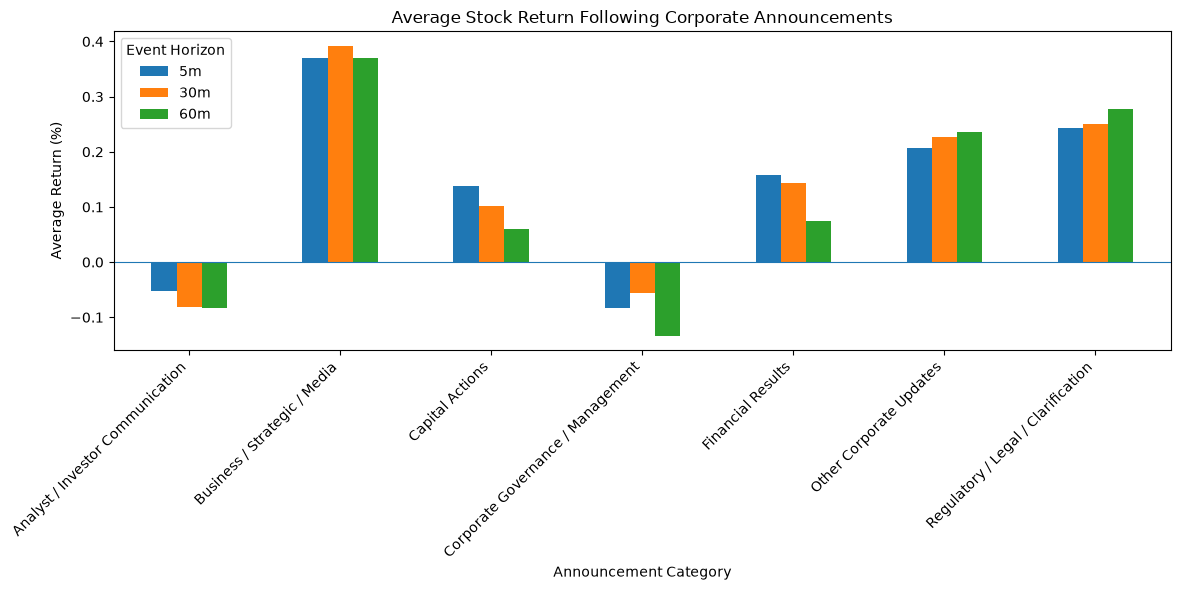

In [72]:
plot_data = final_return.pivot(
    index="subject_group",
    columns="horizon",
    values="mean_return_pct"
)

plot_data = plot_data[["5m", "30m", "60m"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Average Stock Return Following Corporate Announcements")
ax.set_xlabel("Announcement Category")
ax.set_ylabel("Average Return (%)")
ax.axhline(0, linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Event Horizon")
plt.tight_layout()
plt.show()

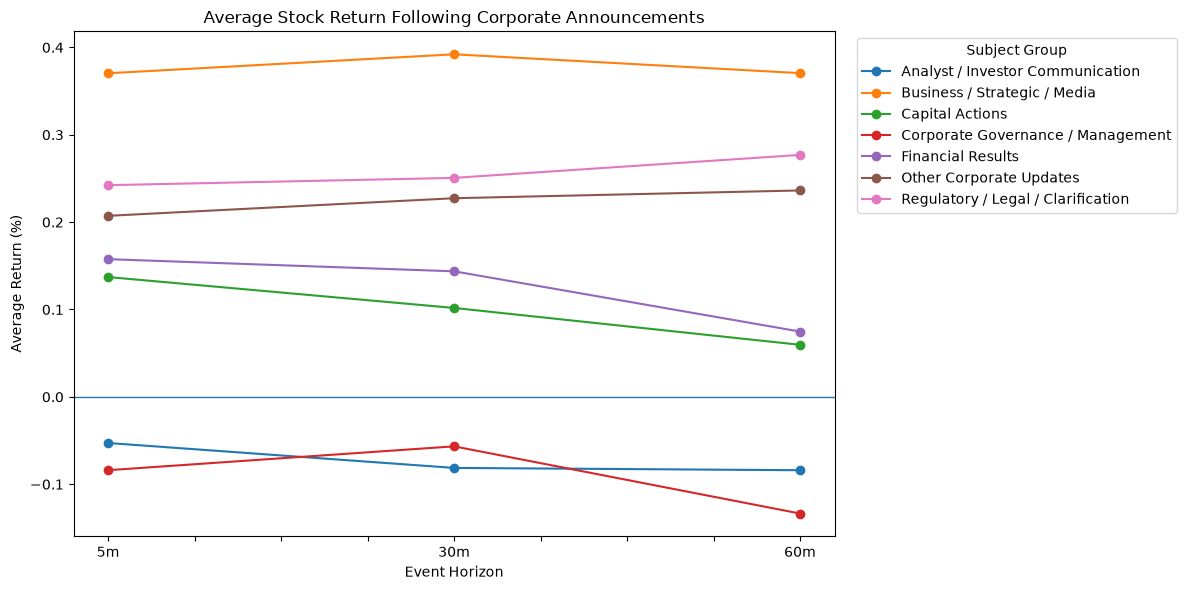

In [73]:
plot_data = final_return.pivot(
    index="subject_group",
    columns="horizon",
    values="mean_return_pct"
)[["5m", "30m", "60m"]]

ax = plot_data.T.plot(
    figsize=(12, 6),
    marker="o"
)

ax.axhline(0, linewidth=1)
ax.set_title("Average Stock Return Following Corporate Announcements")
ax.set_xlabel("Event Horizon")
ax.set_ylabel("Average Return (%)")
plt.legend(title="Subject Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

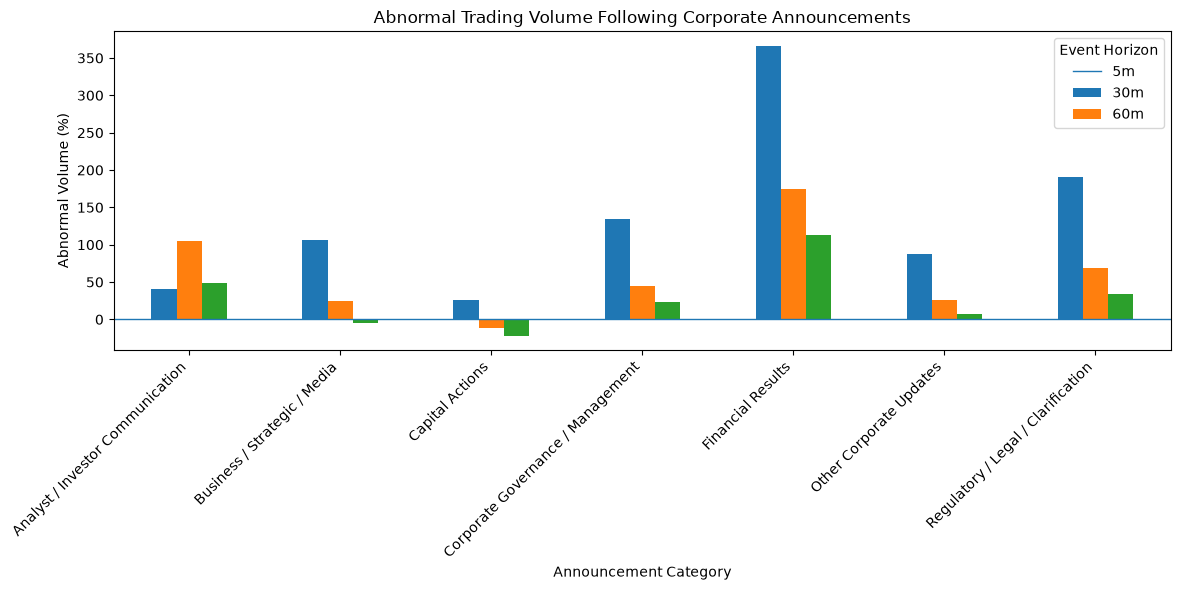

In [74]:
# Calculate mean volume ratio by subject group
volume_plot = volume_window_summary.groupby(
    "subject_group"
)[
    ["volume_ratio_5m", "volume_ratio_30m", "volume_ratio_60m"]
].mean()

# Convert ratio to abnormal volume %
volume_plot = (volume_plot - 1) * 100

# Plot
ax = volume_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.axhline(0, linewidth=1)

ax.set_title("Abnormal Trading Volume Following Corporate Announcements")
ax.set_xlabel("Announcement Category")
ax.set_ylabel("Abnormal Volume (%)")

plt.xticks(rotation=45, ha="right")
plt.legend(
    ["5m", "30m", "60m"],
    title="Event Horizon"
)

plt.tight_layout()
plt.show()

Combined data: (21, 4)


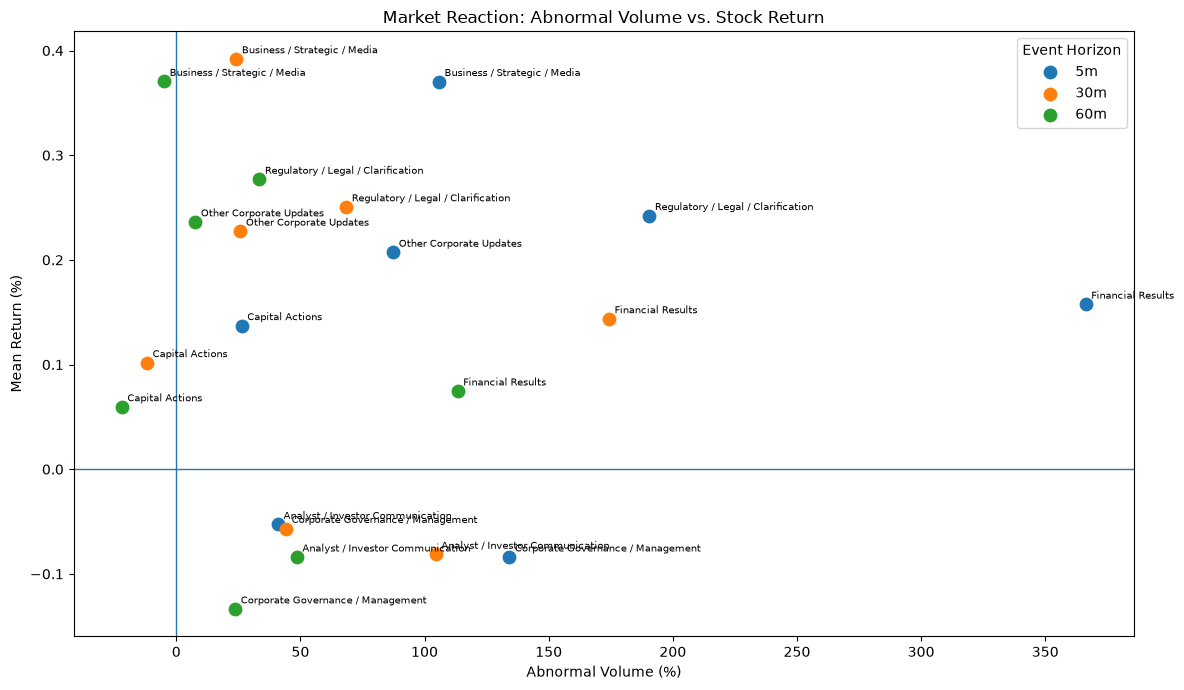

In [75]:
# Prepare return data
return_plot = final_return[
    ["subject_group", "horizon", "mean_return_pct"]
].copy()

# Prepare volume data
volume_plot = volume_window_summary.groupby(
    "subject_group"
)[
    ["volume_ratio_5m", "volume_ratio_30m", "volume_ratio_60m"]
].mean().reset_index()

# Convert volume ratios into abnormal volume %
volume_plot["5m"] = (volume_plot["volume_ratio_5m"] - 1) * 100
volume_plot["30m"] = (volume_plot["volume_ratio_30m"] - 1) * 100
volume_plot["60m"] = (volume_plot["volume_ratio_60m"] - 1) * 100

volume_long = volume_plot.melt(
    id_vars="subject_group",
    value_vars=["5m", "30m", "60m"],
    var_name="horizon",
    value_name="abnormal_volume_pct"
)

# Combine return + volume
combined = return_plot.merge(
    volume_long,
    on=["subject_group", "horizon"],
    how="inner"
)

print("Combined data:", combined.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for horizon in ["5m", "30m", "60m"]:
    data = combined[combined["horizon"] == horizon]

    ax.scatter(
        data["abnormal_volume_pct"],
        data["mean_return_pct"],
        label=horizon,
        s=80
    )

    # Add category labels
    for _, row in data.iterrows():
        ax.annotate(
            row["subject_group"],
            (row["abnormal_volume_pct"], row["mean_return_pct"]),
            fontsize=7,
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_title("Market Reaction: Abnormal Volume vs. Stock Return")
ax.set_xlabel("Abnormal Volume (%)")
ax.set_ylabel("Mean Return (%)")
ax.legend(title="Event Horizon")

plt.tight_layout()
plt.show()

In [76]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("\nIndependent events:", len(volume_window_summary))
print("Unique event IDs:", volume_window_summary["event_id"].nunique())

print("\nMissing values:")
print(volume_window_summary.isna().sum())

print("\nDuplicate event IDs:",
      volume_window_summary["event_id"].duplicated().sum())

print("\nReturn observations:")
print("5m :", len(return_plot[return_plot["horizon"] == "5m"]))
print("30m:", len(return_plot[return_plot["horizon"] == "30m"]))
print("60m:", len(return_plot[return_plot["horizon"] == "60m"]))

print("\n========== CHECK COMPLETE ==========")

========== FINAL DATA QUALITY CHECK ==========

Independent events: 1743
Unique event IDs: 1743

Missing values:
event_id            0
baseline_volume     0
post_5m_volume      0
post_30m_volume     0
post_60m_volume     0
volume_ratio_5m     0
volume_ratio_30m    0
volume_ratio_60m    0
subject_group       0
log_ratio_5m        0
log_ratio_30m       0
log_ratio_60m       0
dtype: int64

Duplicate event IDs: 0

Return observations:
5m : 7
30m: 7
60m: 7

========== CHECK COMPLETE ==========


## 12. Conclusion

**1. Do corporate announcements generate abnormal short-term stock returns?**
Yes, but only for specific announcement types — not for corporate announcements as a whole. After Benjamini-Hochberg correction, 7 of 21 subject-group × horizon combinations show a statistically significant return: **Other Corporate Updates** (significant at all three horizons, mean return +0.21% to +0.24%), **Regulatory / Legal / Clarification** (significant at all three horizons, +0.24% to +0.28%), and **Business / Strategic / Media** (significant at 5m and 30m, ~+0.37–0.39%, marginal at 60m with p_adj = 0.07). Financial Results, Capital Actions, Corporate Governance/Management, and Analyst/Investor Communication show no significant price reaction at any horizon once corrected for multiple testing.

**2. Does the market reaction differ by announcement type?**
Substantially. The point estimates range from roughly **+0.39%** (Business/Strategic/Media) down to **-0.13%** (Corporate Governance/Management at 60m), and only three of the seven categories carry a statistically reliable signal. Financial Results and Capital Actions look directionally positive but never clear the significance bar — likely underpowered relative to the noisier, larger groups. Corporate Governance/Management and Analyst/Investor Communication trend slightly negative but are not distinguishable from zero.

**3. How does trading volume change following announcements?**
Far more consistently than price does — 14 of 21 combinations are significant. Nearly every category shows a sharp abnormal volume spike in the first 5 minutes (Financial Results +89%, Regulatory/Legal +50%, Corporate Governance +36%, Other Corporate Updates +23%, all significant), but this activity fades quickly: by 30–60 minutes, volume in most categories drops back toward or below baseline (e.g. Capital Actions -44%, Analyst/Investor -39%, Other Corporate Updates -28% at 60m, all significant). Volume reacts to nearly all announcement types; price only reacts persistently to a subset.

**4. Are the effects statistically significant after correcting for multiple comparisons?**
Yes, and the correction changed the picture meaningfully — several borderline results (e.g. Capital Actions' raw p = 0.039 at 5m) did not survive FDR correction, confirming they were not distinguishable from noise once tested across all 21 combinations. What remains significant (7/21 for returns, 14/21 for volume) reflects a more conservative, defensible set of findings.

**5. Is there evidence of Post-Earnings Announcement Drift (PEAD)?**
Yes, within the Financial Results sample. The PEAD analysis covers **218 Financial Results events**. Mean cumulative returns are negative and statistically insignificant at D+1 (-0.0874%, adjusted p = 0.5940) and positive but statistically insignificant at D+3 (+0.3420%, adjusted p = 0.2409). A statistically significant positive drift emerges from D+5 onward: **+0.8187% at D+5, +1.1106% at D+10, and +1.4547% at D+20**, with FDR-adjusted p-values of **0.0475** at each horizon. These results provide evidence consistent with PEAD in this sample: positive post-earnings performance becomes apparent several trading days after Financial Results announcements rather than immediately following the event. These are cumulative raw stock returns from the D0 closing price, not market-adjusted abnormal returns.

**6. Are the findings robust to extreme observations?**
Yes. Winsorizing returns at the 1st/99th percentile shifted the mean by only a few percent for most groups (the largest shift was ~23% for the smaller Corporate Governance group), and the three statistically significant return categories — Other Corporate Updates, Regulatory/Legal/Clarification, and Business/Strategic/Media — remained significant with comparable or even slightly stronger t-statistics after winsorizing. Only 1 of 1,743 independent events had a return beyond ±10%. The results are not being driven by a handful of outliers.

**Limitations:** the sample covers 5 stocks (RELIANCE, HDFCBANK, NYKAA, RVNL, HAL) over the available data window, so results may not generalize to the broader market. Subject-group sample sizes are uneven (from n=35 for Business/Strategic/Media to n=643 for Other Corporate Updates), which limits statistical power for the smaller categories. The PEAD analysis is based on 218 Financial Results events and uses cumulative raw stock returns rather than market-adjusted abnormal returns, so the PEAD result should be interpreted as evidence consistent with post-earnings drift rather than definitive proof of abnormal performance. Volume and return effects were tested independently; this analysis does not establish that the volume spike causes the price move, only that both occur around the same announcements.

In [77]:
print("Current DataFrames:")
print([
    name for name, obj in globals().items()
    if hasattr(obj, "shape") and hasattr(obj, "columns")
])

Current DataFrames:
['__', 'announcements', 'df', 'duplicate_ids', '_8', 'raw_announcements', 'different', 'gaps', 'zero_volume', 'ann', 'events', 'daily_counts', 'df_stock', 'group', 'prices', 'window', 'event_windows', 'event_returns', 'subject_counts', 'events_clustered', 'independent_events', 'event_results', 'subject_price_summary', 'direction_summary', 'subject_uncertainty', 'significance_results', 'volume_impact', 'volume_results', 'event_subjects', 'volume_summary', 'volume_window_summary', 'volume_subject_summary', 'volume_significance', 'volume_significance_final', 'return_results', 'volume_results_final', 'combined_results', 'combined_summary', 'duplicates', 'extreme', 'robust_results', 'subset', 'final_return', 'plot_data', 'volume_plot', 'return_plot', 'volume_long', 'combined', 'data']


In [78]:
print("Independent events:")
print(independent_events.shape)
print(independent_events.columns.tolist())

print("\nAvailable stock data:")
print(df_stock.shape)
print(df_stock.columns.tolist())

print("\nEvent returns:")
print(event_returns.shape)
print(event_returns.columns.tolist())

Independent events:
(1743, 36)
['NEWSID', 'SCRIP_CD', 'XML_NAME', 'NEWSSUB', 'DT_TM', 'NEWS_DT', 'CRITICALNEWS', 'ANNOUNCEMENT_TYPE', 'QUARTER_ID', 'FILESTATUS', 'ATTACHMENTNAME', 'MORE', 'HEADLINE', 'CATEGORYNAME', 'OLD', 'RN', 'PDFFLAG', 'NSURL', 'SLONGNAME', 'AGENDA_ID', 'News_submission_dt', 'DissemDT', 'TimeDiff', 'Fld_Attachsize', 'SUBCATNAME', 'BSENewsid', 'Investor_Presentation', 'AUDIO_VIDEO_FILE', 'ticker', 'market_timing', 'event_time_correct', 'event_index', 'subject_group', 'event_cluster', 'cluster_size', 'event_id']

Available stock data:
(277509, 9)
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index']

Event returns:
(2528, 6)
['event_id', 'ticker', 'event_time', 'return_5m', 'return_30m', 'return_60m']


## 13. Post-Earnings Announcement Drift (PEAD) Analysis

In [79]:
print("df columns:")
print(df.columns.tolist())

print("\nprices columns:")
print(prices.columns.tolist())

print("\nevent_windows columns:")
print(event_windows.columns.tolist())

df columns:
['ticker', 'trading_date', 'announcement_count']

prices columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index']

event_windows columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index', 'ticker', 'event_id', 'event_time', 'event_minute', 'baseline_volume', 'volume_ratio', 'abnormal_volume_pct']


In [80]:
print("event_windows rows:", len(event_windows))
print("\nTickers:")
print(event_windows["ticker"].unique())

print("\nEvent date range:")
print(event_windows["event_time"].min())
print(event_windows["event_time"].max())

print("\nIndependent event dates:")
print(independent_events["event_time_correct"].min())
print(independent_events["event_time_correct"].max())

event_windows rows: 230048

Tickers:
<StringArray>
['HAL', 'HDFCBANK', 'NYKAA', 'RELIANCE', 'RVNL']
Length: 5, dtype: str

Event date range:
2023-08-22 09:15:00
2026-08-19 09:15:00

Independent event dates:
2023-08-22 09:15:00
2026-08-19 09:15:00


In [81]:
# Find loaded DataFrames containing ticker, date, and close

for name, obj in list(globals().items()):
    if hasattr(obj, "columns"):
        cols = list(obj.columns)
        if "ticker" in cols and "close" in cols:
            print(name, obj.shape)
            print(cols)
            print()

window (91, 13)
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index', 'ticker', 'event_id', 'event_time', 'event_minute']

event_windows (230048, 16)
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index', 'ticker', 'event_id', 'event_time', 'event_minute', 'baseline_volume', 'volume_ratio', 'abnormal_volume_pct']



In [82]:
print("Available variables containing stock/price data:\n")

for name, obj in list(globals().items()):
    if hasattr(obj, "shape") and hasattr(obj, "columns"):
        cols = list(obj.columns)

        if any(x in name.lower() for x in ["stock", "price", "reliance", "hal", "rvnl", "nykaa", "hdfc"]):
            print(name, obj.shape)
            print(cols)
            print()

Available variables containing stock/price data:

df_stock (277509, 9)
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index']

prices (277509, 9)
['date', 'open', 'high', 'low', 'close', 'volume', 'oi', 'return', 'bar_index']

subject_price_summary (7, 7)
['n_events', 'mean_5m', 'median_5m', 'mean_30m', 'median_30m', 'mean_60m', 'median_60m']



In [83]:
# ============================================================
# PEAD: Create daily closing-price dataset from original stocks
# ============================================================

daily_stock_list = []

for ticker, stock_data in stocks.items():
    temp = stock_data.copy()

    temp["date"] = pd.to_datetime(temp["date"])
    temp["trading_date"] = temp["date"].dt.normalize()

    # Last available market price of each trading day
    daily = (
        temp
        .sort_values("date")
        .groupby("trading_date", as_index=False)
        .agg(
            daily_close=("close", "last")
        )
    )

    daily["ticker"] = ticker

    daily_stock_list.append(daily)

daily_stock = pd.concat(
    daily_stock_list,
    ignore_index=True
)

# Calculate daily simple returns separately for each stock
daily_stock = daily_stock.sort_values(
    ["ticker", "trading_date"]
).reset_index(drop=True)

daily_stock["daily_return"] = (
    daily_stock
    .groupby("ticker")["daily_close"]
    .pct_change()
)

print("Daily stock dataset created successfully.")
print("Shape:", daily_stock.shape)
print("\nColumns:")
print(daily_stock.columns.tolist())

display(daily_stock.head(10))

Daily stock dataset created successfully.
Shape: (3720, 4)

Columns:
['trading_date', 'daily_close', 'ticker', 'daily_return']


,trading_date,daily_close,ticker,daily_return
0,2023-08-21,1913.5,HAL,NaN
1,2023-08-22,1946.5,HAL,0.017246
2,2023-08-23,2020.3,HAL,0.037914
3,2023-08-24,1983.5,HAL,-0.018215
4,2023-08-25,1950.0,HAL,-0.016889
5,2023-08-28,1955.0,HAL,0.002564
6,2023-08-29,1951.8,HAL,-0.001637
7,2023-08-30,1951.5,HAL,-0.000154
8,2023-08-31,1956.0,HAL,0.002306
9,2023-09-01,1973.0,HAL,0.008691


In [84]:
# ============================================================
# PEAD: Calculate cumulative returns after earnings events
# Horizons: D0, D+1, D+3, D+5, D+10, D+20
# ============================================================

# Keep only Financial Results announcements
financial_events = independent_events[
    independent_events["subject_group"] == "Financial Results"
].copy()

financial_events["event_date"] = (
    pd.to_datetime(financial_events["event_time_correct"])
    .dt.normalize()
)

# Prepare daily stock data
daily_stock = daily_stock.sort_values(
    ["ticker", "trading_date"]
).reset_index(drop=True)

# Create a lookup of trading dates for each stock
trading_dates = {
    ticker: group["trading_date"].tolist()
    for ticker, group in daily_stock.groupby("ticker")
}

# Calculate cumulative return from event day to each horizon
pead_rows = []

for _, event in financial_events.iterrows():

    ticker = event["ticker"]
    event_date = event["event_date"]

    if ticker not in trading_dates:
        continue

    dates = trading_dates[ticker]

    # Find the event trading date
    matching_dates = [
        d for d in dates
        if d >= event_date
    ]

    if len(matching_dates) == 0:
        continue

    d0 = matching_dates[0]
    d0_position = dates.index(d0)

    # Required PEAD horizons
    horizons = {
        "D0": 0,
        "D+1": 1,
        "D+3": 3,
        "D+5": 5,
        "D+10": 10,
        "D+20": 20
    }

    row = {
        "event_id": event["event_id"],
        "ticker": ticker,
        "event_date": event_date,
        "subject_group": event["subject_group"]
    }

    for horizon_name, offset in horizons.items():

        target_position = d0_position + offset

        if target_position >= len(dates):
            row[f"return_{horizon_name}"] = np.nan
            continue

        target_date = dates[target_position]

        start_price = daily_stock[
            (daily_stock["ticker"] == ticker) &
            (daily_stock["trading_date"] == d0)
        ]["daily_close"].iloc[0]

        end_price = daily_stock[
            (daily_stock["ticker"] == ticker) &
            (daily_stock["trading_date"] == target_date)
        ]["daily_close"].iloc[0]

        row[f"return_{horizon_name}"] = (
            end_price / start_price
        ) - 1

    pead_rows.append(row)

pead_results = pd.DataFrame(pead_rows)

print("PEAD events:", len(pead_results))
print("Columns:")
print(pead_results.columns.tolist())

display(
    pead_results.head()
)

PEAD events: 218
Columns:
['event_id', 'ticker', 'event_date', 'subject_group', 'return_D0', 'return_D+1', 'return_D+3', 'return_D+5', 'return_D+10', 'return_D+20']


,event_id,ticker,event_date,subject_group,return_D0,return_D+1,return_D+3,return_D+5,return_D+10,return_D+20
0,2320,HAL,2023-10-27,Financial Results,0.0,-0.009706,-0.015961,0.024643,0.108655,0.212726
1,2262,HAL,2023-11-10,Financial Results,0.0,0.009484,0.016537,0.032320,0.093872,0.359436
2,2046,HAL,2024-02-12,Financial Results,0.0,0.025845,0.062388,0.065484,0.074633,0.186319
3,1807,HAL,2024-05-03,Financial Results,0.0,-0.025572,-0.015884,-0.011804,0.154935,0.277057
4,1777,HAL,2024-05-16,Financial Results,0.0,-0.023265,0.029561,0.067078,0.074624,0.102870


In [85]:
# ============================================================
# PEAD: Summary statistics and significance testing
# ============================================================

from scipy import stats

pead_horizons = [
    "D0",
    "D+1",
    "D+3",
    "D+5",
    "D+10",
    "D+20"
]

pead_summary = []

for horizon in pead_horizons:

    values = pead_results[f"return_{horizon}"].dropna()

    t_stat, p_value = stats.ttest_1samp(
        values,
        0
    )

    pead_summary.append({
        "horizon": horizon,
        "n_events": len(values),
        "mean_return": values.mean(),
        "median_return": values.median(),
        "std_return": values.std(),
        "t_stat": t_stat,
        "p_value": p_value
    })

pead_summary = pd.DataFrame(pead_summary)

# Multiple-testing correction
pead_summary["p_value_adj"] = multipletests(
    pead_summary["p_value"],
    method="fdr_bh"
)[1]

pead_summary["significant_5pct"] = (
    pead_summary["p_value_adj"] < 0.05
)

display(
    pead_summary.style.format({
        "mean_return": "{:.4%}",
        "median_return": "{:.4%}",
        "std_return": "{:.4%}",
        "t_stat": "{:.3f}",
        "p_value": "{:.4f}",
        "p_value_adj": "{:.4f}"
    })
)

,horizon,n_events,mean_return,median_return,std_return,t_stat,p_value,p_value_adj,significant_5pct
0,D0,218,0.0000%,0.0000%,0.0000%,nan,nan,nan,False
1,D+1,218,-0.0874%,-0.3857%,2.4167%,-0.534,0.5940,nan,False
2,D+3,217,0.3420%,0.1294%,3.8553%,1.307,0.1927,nan,False
3,D+5,217,0.8187%,0.2667%,5.4447%,2.215,0.0278,nan,False
4,D+10,213,1.1106%,-0.0559%,7.0680%,2.293,0.0228,nan,False
5,D+20,209,1.4547%,-0.4352%,9.5351%,2.206,0.0285,nan,False


In [86]:
# ============================================================
# PEAD: Correct multiple-testing adjustment
# Exclude D0 because its return is mechanically 0%
# ============================================================

pead_test_results = pead_summary[
    pead_summary["horizon"] != "D0"
].copy()

pead_test_results["p_value_adj"] = multipletests(
    pead_test_results["p_value"],
    method="fdr_bh"
)[1]

pead_test_results["significant_5pct"] = (
    pead_test_results["p_value_adj"] < 0.05
)

display(
    pead_test_results.style.format({
        "mean_return": "{:.4%}",
        "median_return": "{:.4%}",
        "std_return": "{:.4%}",
        "t_stat": "{:.3f}",
        "p_value": "{:.4f}",
        "p_value_adj": "{:.4f}"
    })
)

,horizon,n_events,mean_return,median_return,std_return,t_stat,p_value,p_value_adj,significant_5pct
1,D+1,218,-0.0874%,-0.3857%,2.4167%,-0.534,0.5940,0.5940,False
2,D+3,217,0.3420%,0.1294%,3.8553%,1.307,0.1927,0.2409,False
3,D+5,217,0.8187%,0.2667%,5.4447%,2.215,0.0278,0.0475,True
4,D+10,213,1.1106%,-0.0559%,7.0680%,2.293,0.0228,0.0475,True
5,D+20,209,1.4547%,-0.4352%,9.5351%,2.206,0.0285,0.0475,True


### PEAD Findings

The PEAD analysis covers 218 Financial Results events across the five stocks in the sample. Mean cumulative returns are negative and statistically insignificant at D+1 (-0.0874%, adjusted p = 0.5940) and positive but statistically insignificant at D+3 (+0.3420%, adjusted p = 0.2409).

A statistically significant positive drift emerges from D+5 onward. Mean returns are +0.8187% at D+5, +1.1106% at D+10, and +1.4547% at D+20, with FDR-adjusted p-values of 0.0475 at each horizon.

These results provide evidence consistent with Post-Earnings Announcement Drift (PEAD) in the sample: positive abnormal performance becomes apparent several trading days after Financial Results announcements rather than immediately following the event. However, the findings should be interpreted as evidence within this sample rather than proof that PEAD universally exists, given the analysis covers five stocks and 218 events.

### PEAD Return Profile

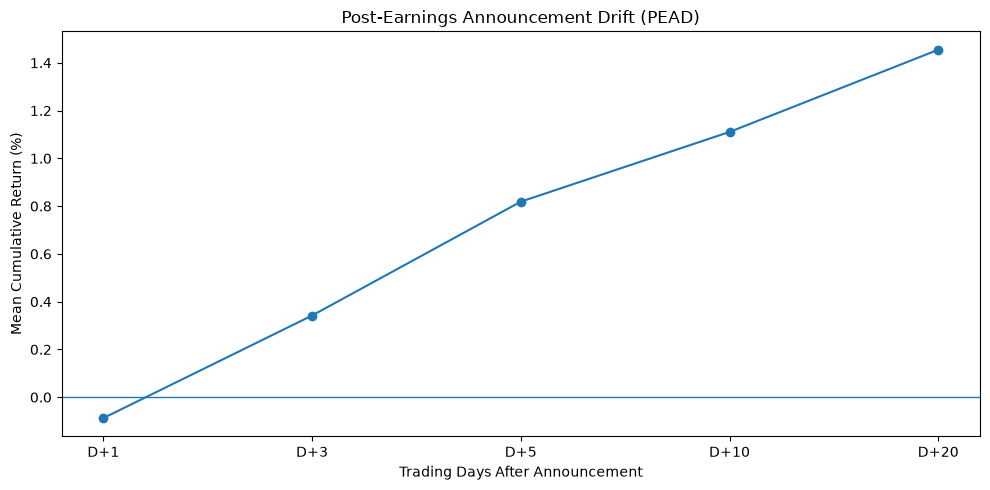

In [87]:
# ============================================================
# PEAD: Return profile across post-event horizons
# ============================================================

import matplotlib.pyplot as plt

plot_pead = pead_test_results.copy()

horizon_order = ["D+1", "D+3", "D+5", "D+10", "D+20"]

plot_pead["horizon"] = pd.Categorical(
    plot_pead["horizon"],
    categories=horizon_order,
    ordered=True
)

plot_pead = plot_pead.sort_values("horizon")

plt.figure(figsize=(10, 5))

plt.plot(
    plot_pead["horizon"],
    plot_pead["mean_return"] * 100,
    marker="o"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Trading Days After Announcement")
plt.ylabel("Mean Cumulative Return (%)")
plt.title("Post-Earnings Announcement Drift (PEAD)")

plt.tight_layout()
plt.show()